# NOTEBOOK to plot the images for the MSC thesis


In [22]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import sacc
import yaml
import numcosmo_py as ncm
from chainconsumer import ChainConsumer, Chain, PlotConfig, Truth

In [23]:
def load_yaml_file(yaml_file: str) -> dict:
    with open(yaml_file, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)
    
def get_6x2pt_sacc(run_names: list) -> list:
    sacc_data_list = []
    for run_name in run_names:
        run_name_split = run_name.split('_')
        run_name_directory = '_'.join(run_name_split[2:])
        sacc_file = f"../runs/{run_name_directory}/sacc_files/{run_name}.sacc"
        try:
            sacc_data = sacc.Sacc.load_fits(sacc_file)
            sacc_data_list.append(sacc_data)
        except FileNotFoundError:
            print(f"Warning: File {sacc_file} not found. Skipping this run.")
        except Exception as e:
            print(f"Error loading {sacc_file}: {e}. Skipping this run.")
    
    return sacc_data_list

def get_sacc_plots(list_run_name_):
    sacc_list = []
    for _run_name in list_run_name_:
        try:
            sacc_data = get_6x2pt_sacc([_run_name])  # Pass a list with a single run name
            sacc_list.append(sacc_data[0])  # Extract the first (and only) element
        except Exception as e:
            print(f"Error loading SACC data for {_run_name}: {e}")
    
    if sacc_list:
        get_tracer_plots(sacc_list, list_run_name_)
        get_c_ell_plots(sacc_list, list_run_name_)
        get_correlation_plot(sacc_list, list_run_name_)
    else:
        print("No valid SACC data found to plot.")

def get_tracer_plots(list_sacc_data_, list_run_names):
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(26, 18))
    colors = {'lens': 'C3', 'src': 'C4', 'spec_bgs': 'C0', 'spec_lrg': 'C1', 'spec_elg': 'C2'}
    
    # Define line styles for each run
    line_styles = ['-', '--', '-.', ':']
    
    # Verifica se o número de SACC data e run names coincide
    if len(list_sacc_data_) != len(list_run_names):
        raise ValueError("O número de SACC data e run names deve ser o mesmo.")
    
    # Itera sobre cada SACC data e run name
    for idx, (_sacc_data_, run_name) in enumerate(zip(list_sacc_data_, list_run_names)):
        # Define o estilo de linha para este run
        line_style = line_styles[idx % len(line_styles)]
        
        for tr in _sacc_data_.tracers:
            try:
                tracer = _sacc_data_.get_tracer(tr)
                if tr.startswith("lens"):
                    ax[0].plot(tracer.z, tracer.nz, 
                               label=f'LSST lens', color=colors['lens'], 
                               linestyle=line_style, alpha=0.7)
                if tr.startswith("src"):
                    ax[1].plot(tracer.z, tracer.nz, 
                               label=f'LSST source', color=colors['src'], 
                               linestyle=line_style, alpha=0.7)
                if tr.startswith("spec_bgs"):
                    ax[2].plot(tracer.z, tracer.nz, 
                               label=f'DESI BGS', color=colors['spec_bgs'], 
                               linestyle=line_style, alpha=0.7)
                if tr.startswith("spec_lrg"):
                    ax[2].plot(tracer.z, tracer.nz, 
                               label=f'DESI LRG', color=colors['spec_lrg'], 
                               linestyle=line_style, alpha=0.7)
                if tr.startswith("spec_elg"):
                    ax[2].plot(tracer.z, tracer.nz, 
                               label=f'DESI ELG', color=colors['spec_elg'], 
                               linestyle=line_style, alpha=0.7)
            except Exception as e:
                print(f"Error processing tracer {tr} for run {run_name}: {e}")
    
    # Configurações dos subplots
    titles = ['LSST-LIKE Lens sample', 'LSST-LIKE Source sample', 'DESI-LIKE sample']
    for i in range(3):
        ax[i].set_ylabel('dN/dz', fontsize=20)
        ax[i].set_xlabel('z', fontsize=20)
        ax[i].set_xlim(0, 2.5)
        ax[i].tick_params(labelsize=18)
        ax[i].grid(True, linestyle='--', alpha=0.6)
        ax[i].set_title(titles[i], fontsize=24)
        
        # Remove legendas duplicadas
        handles, labels = ax[i].get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax[i].legend(by_label.values(), by_label.keys(), loc='upper right', frameon=False, fontsize=20)
    
    plt.tight_layout()
    plt.show()

def c_ell_auxiliary_plot(_list_tracer_comb_, list_sacc_data_, list_run_names):
    size = len(_list_tracer_comb_)
    if size == 0:
        print("No tracer combinations found.")
        return
    
    # Verifica se o número de SACC data e run names coincide
    if len(list_sacc_data_) != len(list_run_names):
        raise ValueError("O número de SACC data e run names deve ser o mesmo.")
    
    # Define estilos de linha e cores para cada run
    line_styles = ['-', '--', '-.', ':']
    colors = ['b', 'g', 'r', 'c', 'm', 'y', 'k']  # Cores básicas
    
    # Configuração dos subplots
    nrows = (size // 5) + 1 if size % 5 != 0 else size // 5
    fig, axs = plt.subplots(nrows, 5, figsize=(24, 4 * nrows))
    
    # Se axs for 1D, transforme-o em 2D para consistência
    if nrows == 1:
        axs = axs.reshape(1, -1)
    
    # Itera sobre cada combinação de tracers
    for i, (t1, t2) in enumerate(_list_tracer_comb_):
        row = i // 5
        col = i % 5
        
        for idx, (_sacc_data_, run_name) in enumerate(zip(list_sacc_data_, list_run_names)):
            # Verifica se a combinação de tracers existe neste run
            if (t1 in _sacc_data_.tracers) and (t2 in _sacc_data_.tracers):
                try:
                    # Define o estilo de linha e cor para este run
                    line_style = line_styles[idx % len(line_styles)]
                    color = colors[idx % len(colors)]
                    
                    # Obtém os dados C_ell
                    l1, cl1, cov1 = _sacc_data_.get_ell_cl(None, t1, t2, return_cov=True)
                    err1 = np.sqrt(np.diag(cov1))
                    
                    # Plota os dados no subplot correto
                    axs[row, col].errorbar(l1, cl1, err1, fmt=line_style, color=color, label=f'{run_name}', alpha=0.8)
                except:
                    # Define o estilo de linha e cor para este run
                    line_style = line_styles[idx % len(line_styles)]
                    color = colors[idx % len(colors)]
                    
                    # Obtém os dados C_ell
                    l1, cl1 = _sacc_data_.get_ell_cl(None, t1, t2, return_cov=False)
                    
                    # Plota os dados no subplot correto
                    axs[row, col].plot(l1, cl1, color=color, label=f'{run_name}', alpha=0.8)
        
        # Configurações do subplot
        axs[row, col].set_title(f'{t1} - {t2}')
        axs[row, col].set_xlim(20, 2000)
        axs[row, col].set_xscale('log')
        axs[row, col].set_yscale('log')
        axs[row, col].set_xlabel('$\ell$')
        axs[row, col].set_ylabel('$\ell C_\ell [10^-9]$')
        axs[row, col].grid(True, linestyle='--', alpha=0.6)
        axs[row, col].legend(loc='upper right', frameon=False)
    
    # Oculta subplots não utilizados
    for i in range(size, nrows * 5):
        row = i // 5
        col = i % 5
        axs[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()

def get_c_ell_plots(list_sacc_data_, list_run_names):
    if len(list_sacc_data_) == 0:
        print("No SACC data provided.")
        return
    
    # Coleta todas as combinações de tracers únicas em todos os runs
    all_tracer_combinations = set()
    for _sacc_data_ in list_sacc_data_:
        all_tracer_combinations.update(_sacc_data_.get_tracer_combinations())
    
    # Converte o conjunto de combinações em uma lista
    all_tracer_combinations = list(all_tracer_combinations)
    
    # Separa as combinações de tracers por tipo
    lens_x_lens = []
    spec_x_lens = []
    spec_x_spec = []
    lens_x_src = []
    spec_x_src = []
    src_x_src = []
    
    for t1, t2 in all_tracer_combinations:
        if t1.startswith("lens") and t2.startswith("lens"):
            lens_x_lens.append((t1, t2))
        if t1.startswith("spec") and t2.startswith("lens"):
            spec_x_lens.append((t1, t2))
        if t1.startswith("spec") and t2.startswith("spec"):
            spec_x_spec.append((t1, t2))
        if t1.startswith("lens") and t2.startswith("src"):
            lens_x_src.append((t1, t2))
        if t1.startswith("spec") and t2.startswith("src"):
            spec_x_src.append((t1, t2))
        if t1.startswith("src") and t2.startswith("src"):
            src_x_src.append((t1, t2))
    
    # Plota as combinações de tracers
    c_ell_auxiliary_plot(lens_x_lens, list_sacc_data_, list_run_names)
    c_ell_auxiliary_plot(spec_x_lens, list_sacc_data_, list_run_names)
    c_ell_auxiliary_plot(spec_x_spec, list_sacc_data_, list_run_names)
    c_ell_auxiliary_plot(lens_x_src, list_sacc_data_, list_run_names)
    c_ell_auxiliary_plot(spec_x_src, list_sacc_data_, list_run_names)
    c_ell_auxiliary_plot(src_x_src, list_sacc_data_, list_run_names)

def get_correlation_plot(list_sacc_data_, list_run_names):
    """
    Plota a matriz de correlação para cada SACC data, diferenciando blocos com base nos índices dos tracers
    e adicionando os nomes das combinações nos eixos x e y.

    Args:
        list_sacc_data_: Lista de objetos sacc.
        list_run_names: Lista de nomes das runs correspondentes.
    """
    # Verifica se o número de SACC data e run names coincide
    if len(list_sacc_data_) != len(list_run_names):
        raise ValueError("O número de SACC data e run names deve ser o mesmo.")
    
    # Número de runs
    num_runs = len(list_sacc_data_)
    
    # Configuração dos subplots
    fig, axs = plt.subplots(1, num_runs, figsize=(10 * num_runs, 8))  # Ajuste o tamanho conforme necessário
    
    # Se houver apenas um run, axs não será uma lista, então transformamos em uma lista
    if num_runs == 1:
        axs = [axs]
    
    # Itera sobre cada SACC data e run name
    for idx, (_sacc_data_, run_name) in enumerate(zip(list_sacc_data_, list_run_names)):
        try:
            # Calcula a matriz de correlação
            cov = _sacc_data_.covariance.dense
            sig = np.sqrt(cov.diagonal())
            corr = cov / np.outer(sig, sig)
            
            # Plota a matriz de correlação no subplot correspondente
            im = axs[idx].imshow(corr, vmin=0, vmax=1, cmap='gnuplot2_r')
            plt.colorbar(im, ax=axs[idx], label='Correlation')
            axs[idx].set_title(f'Correlation Matrix ({run_name})')
            
            # Obtém os rótulos para os eixos x e y
            labels = []
            for dt in _sacc_data_.get_data_types():
                if dt == "galaxy_density_cl":
                    dt = "$C_{gg}(l)$"
                elif dt == "galaxy_shearDensity_cl_e":
                    dt = "$C_{g\gamma}(l)$"
                elif dt == "galaxy_shear_cl_ee":
                    dt = "$C_{\gamma\gamma}(l)$"
                label = f"{dt}"
                labels.append(label)

            # Adiciona linhas divisórias para diferenciar os blocos
            tracer_comb = ["lens"]
            block_indices = []
            for dt in _sacc_data_.get_data_types():
                for tr in _sacc_data_.get_tracer_combinations(dt):
                    # Obtém os índices correspondentes a esta combinação de tracers
                    indices = _sacc_data_.indices(dt, tr)
                    print(f"Indices for {tr}: {indices}")
                if len(indices) > 0:
                    block_indices.append(indices[-1]+ 0.5)  # Fim do bloco desta combinação
            
            # Calcula as posições dos ticks (meio de cada bloco)
            tick_positions = []
            start = 0
            for block in block_indices:
                mid = (start + block) // 2  # Ponto médio do bloco
                tick_positions.append(mid)
                start = block

            # Remove o último índice, pois não precisamos de uma linha no final da matriz
            block_indices = block_indices[:-1]

            # Define os ticks e rótulos nos eixos x e y
            axs[idx].set_xticks(tick_positions)
            axs[idx].set_yticks(tick_positions)
            axs[idx].set_xticklabels(labels, rotation=90, fontsize=10)  # Rótulos no eixo x
            axs[idx].set_yticklabels(labels, fontsize=10)  # Rótulos no eixo y

            # Adiciona linhas divisórias para diferenciar os blocos
            for block in block_indices:
                axs[idx].axvline(x=block, color='grey', linestyle='--', linewidth=0.5)
                axs[idx].axhline(y=block, color='grey', linestyle='--', linewidth=0.5)
        except Exception as e:
            print(f"Error processing correlation matrix for run {run_name}: {e}")
    
    plt.tight_layout()
    plt.show()


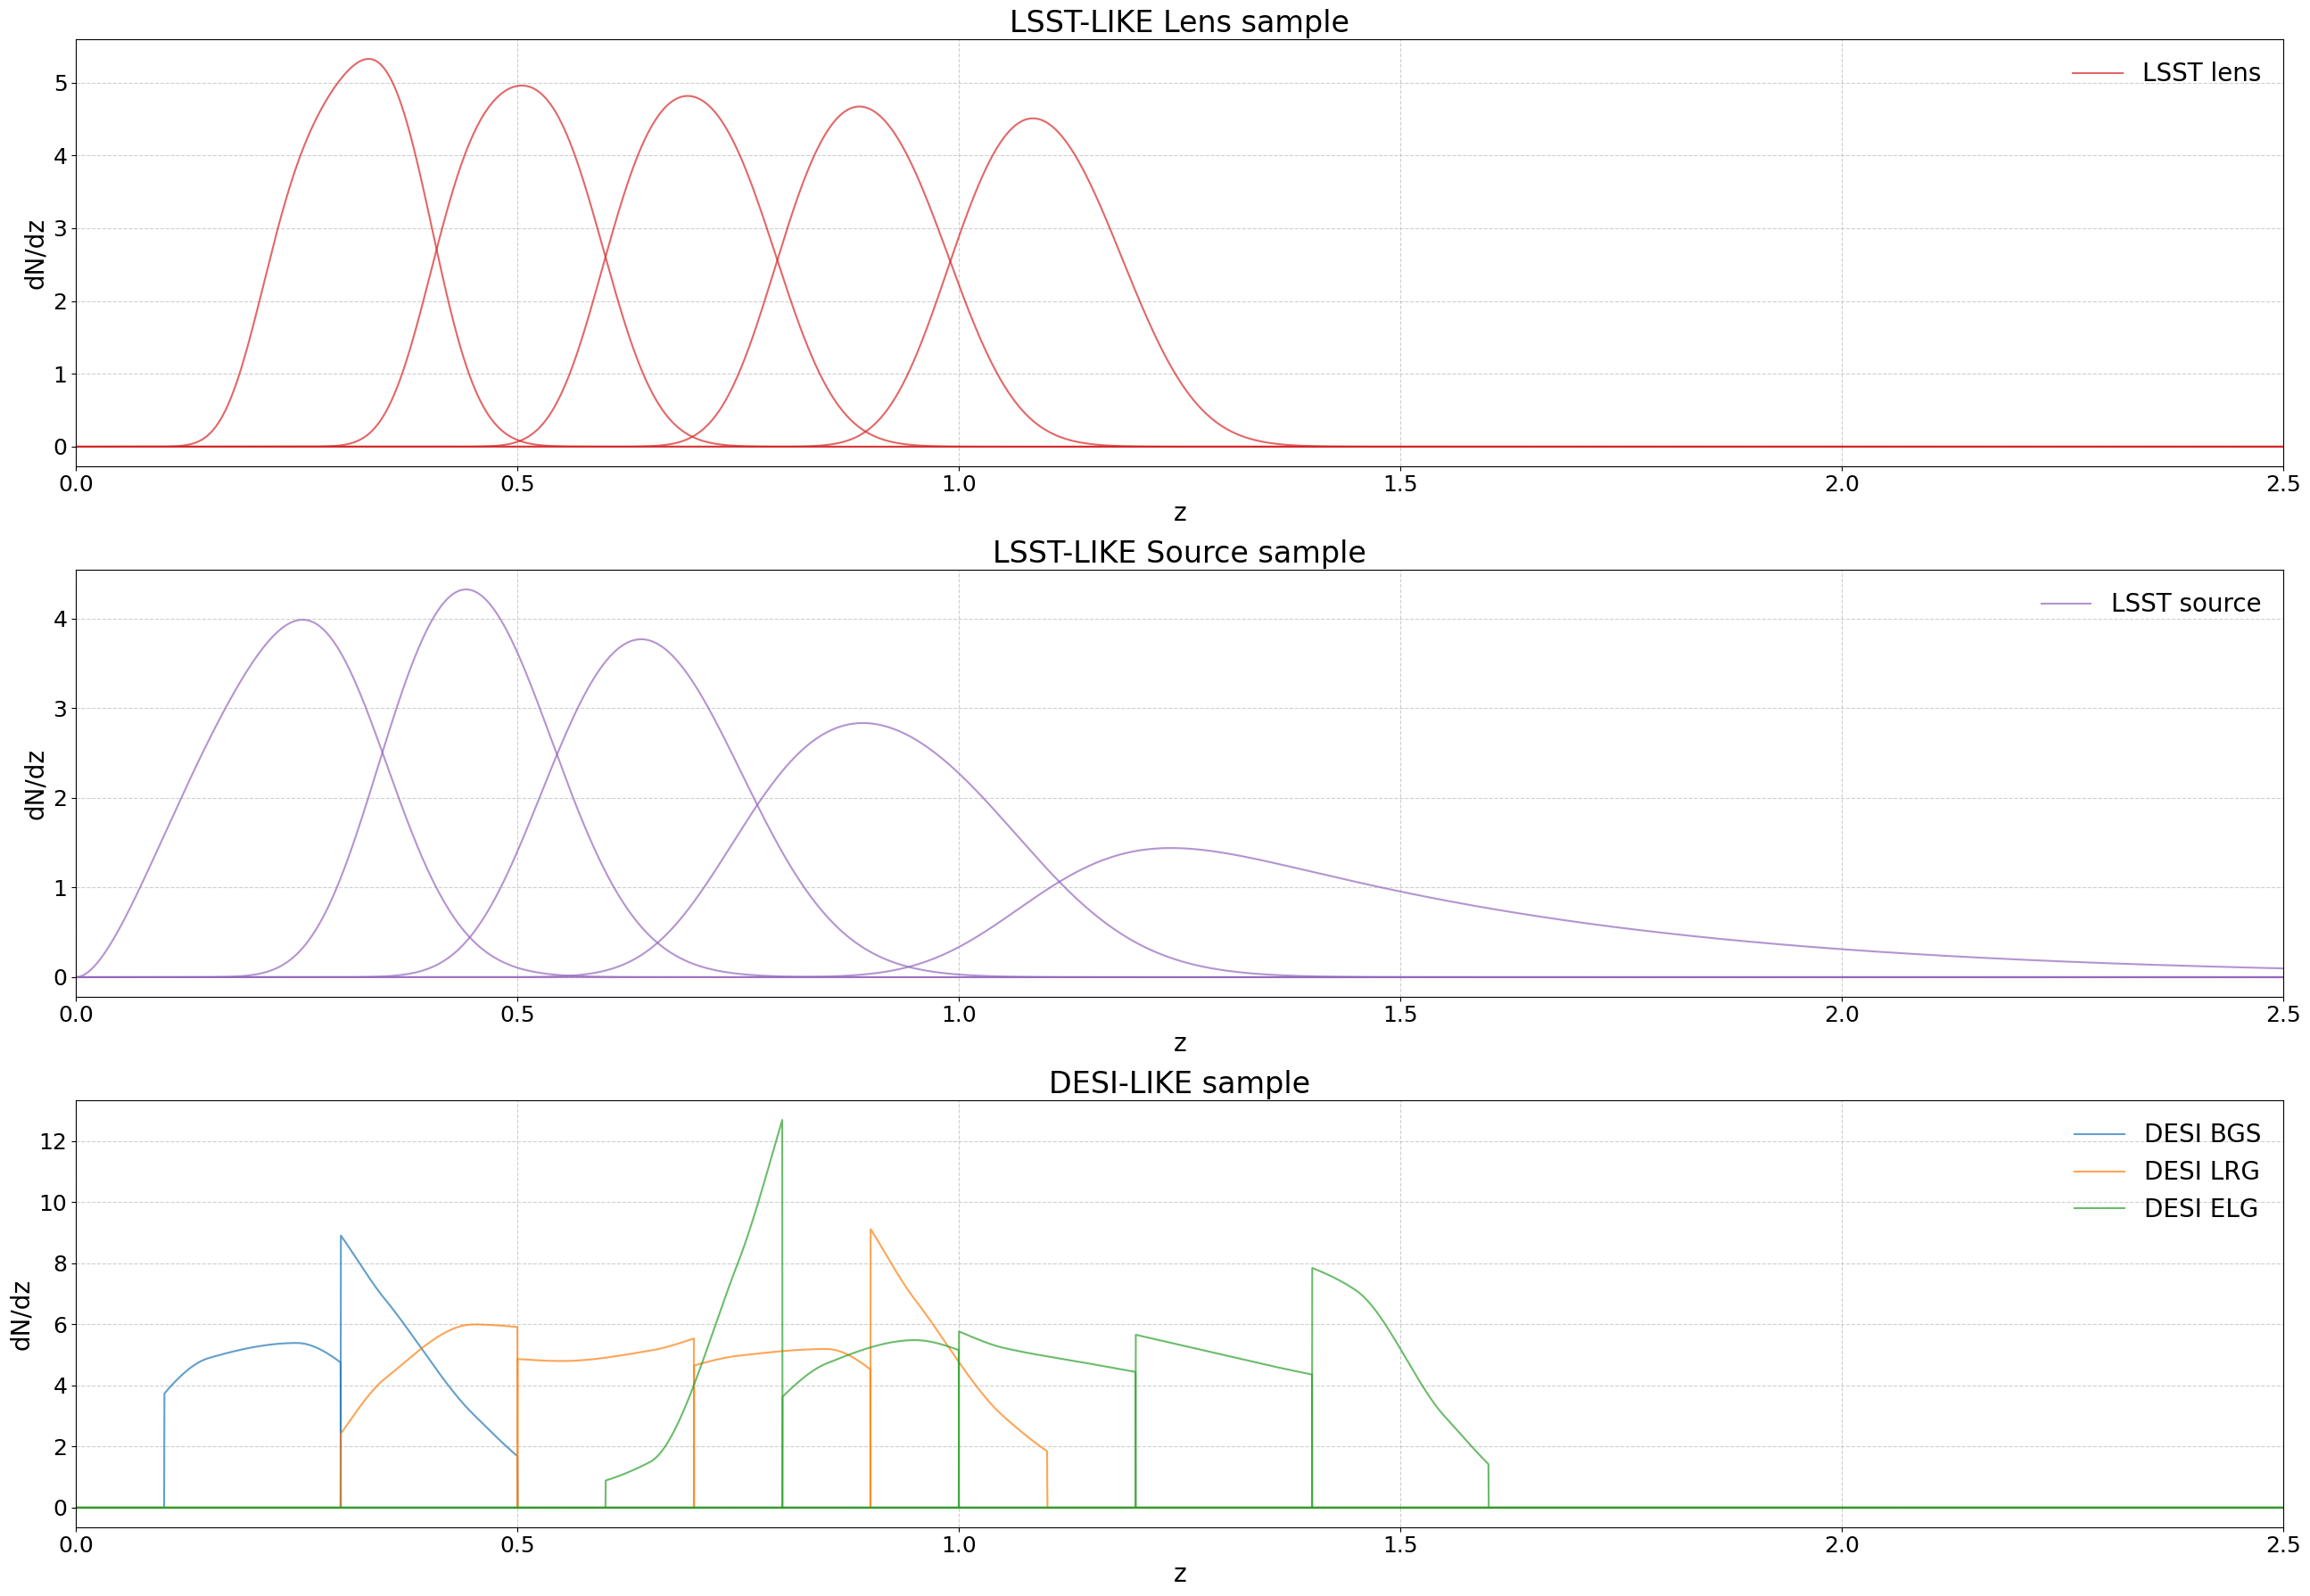

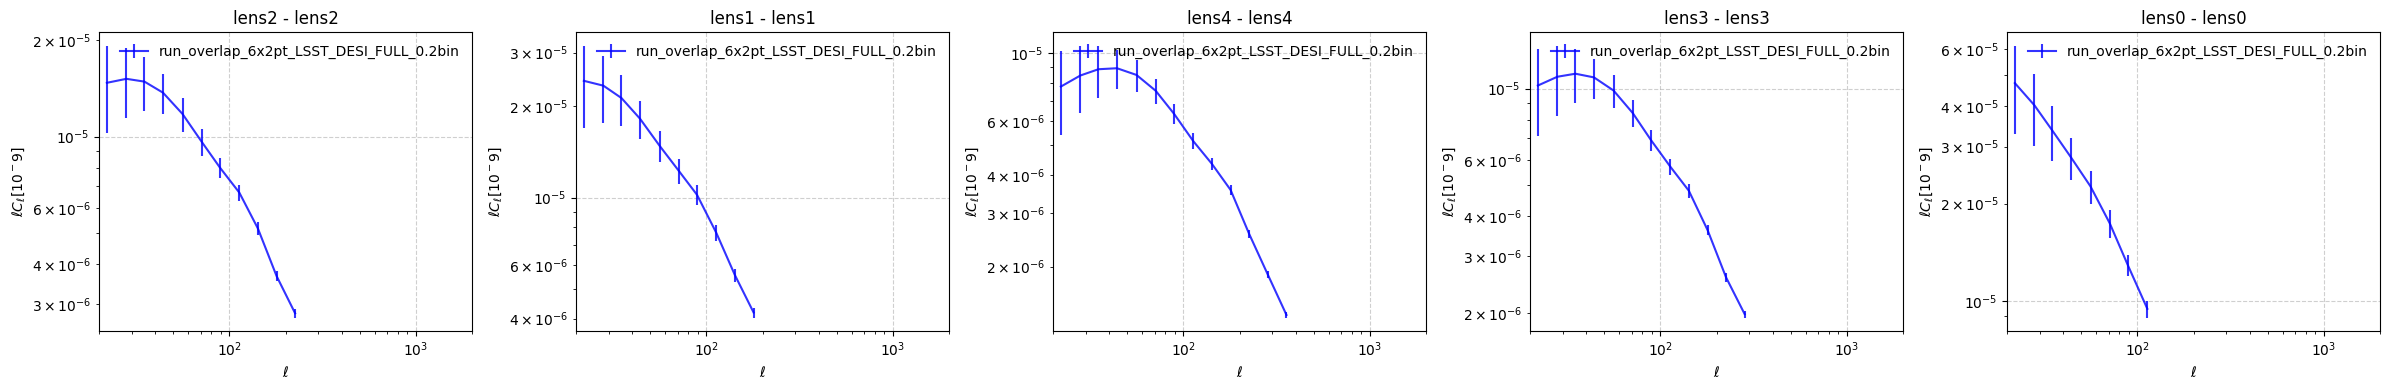

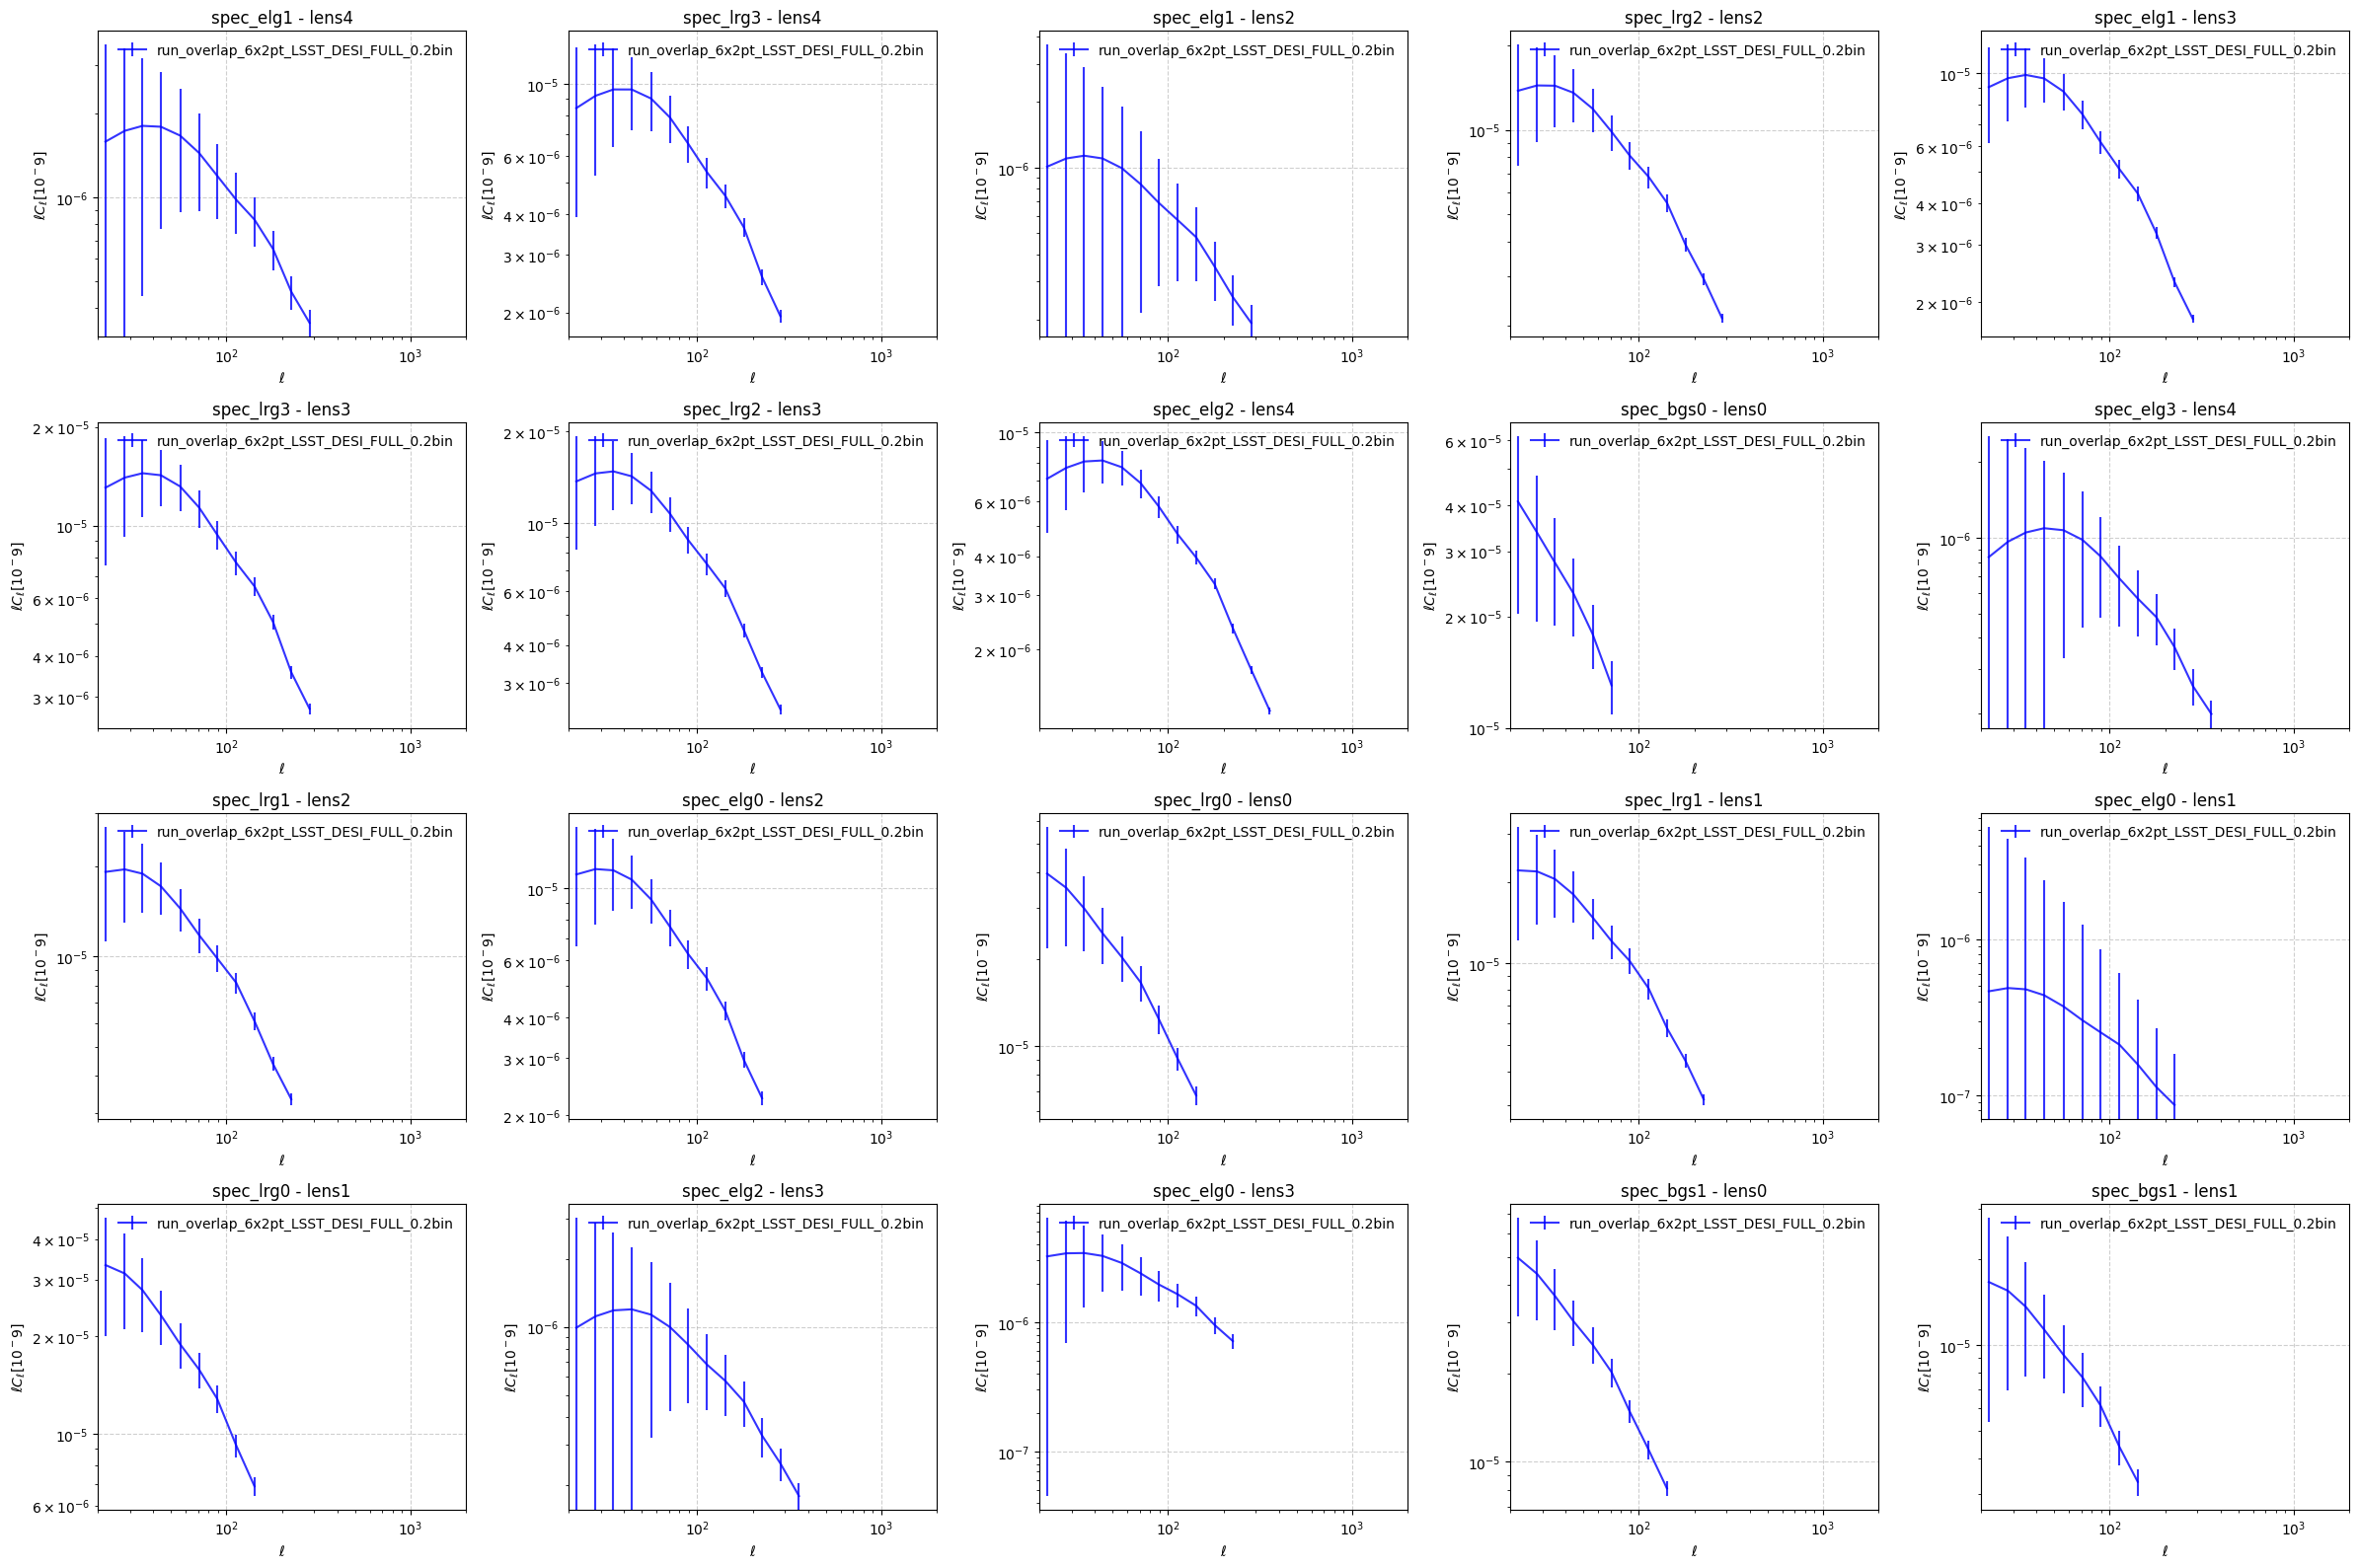

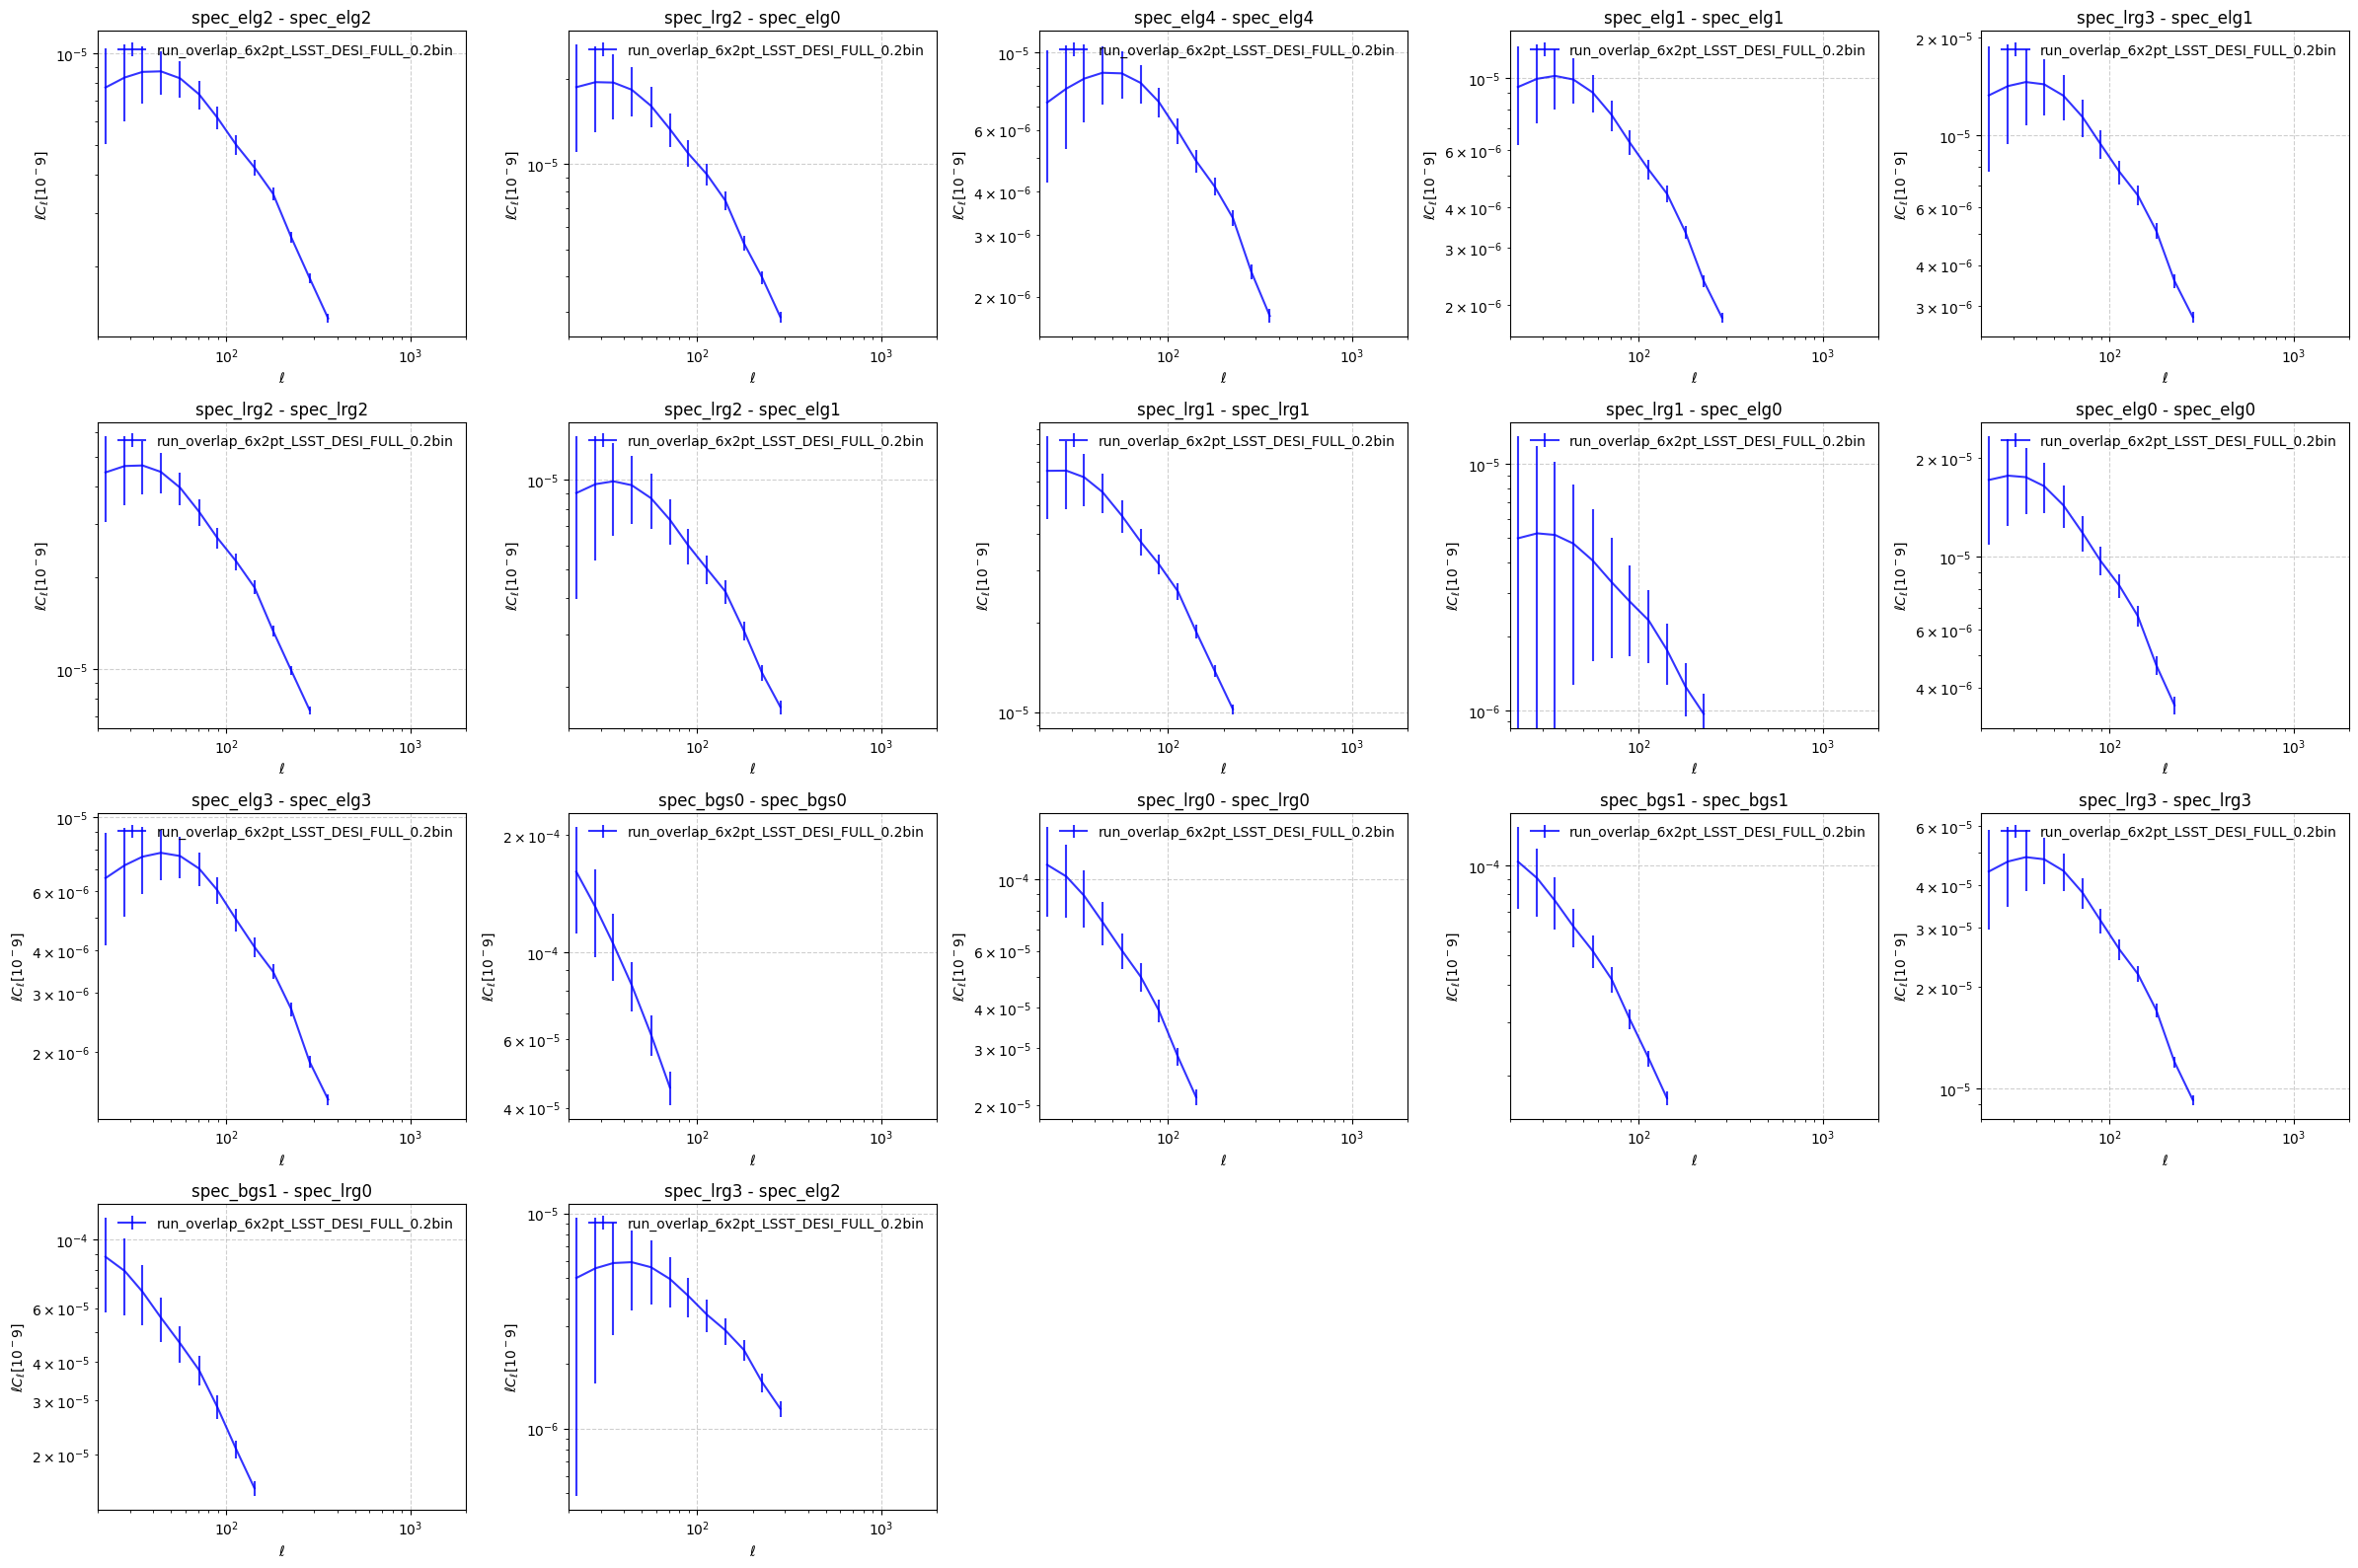

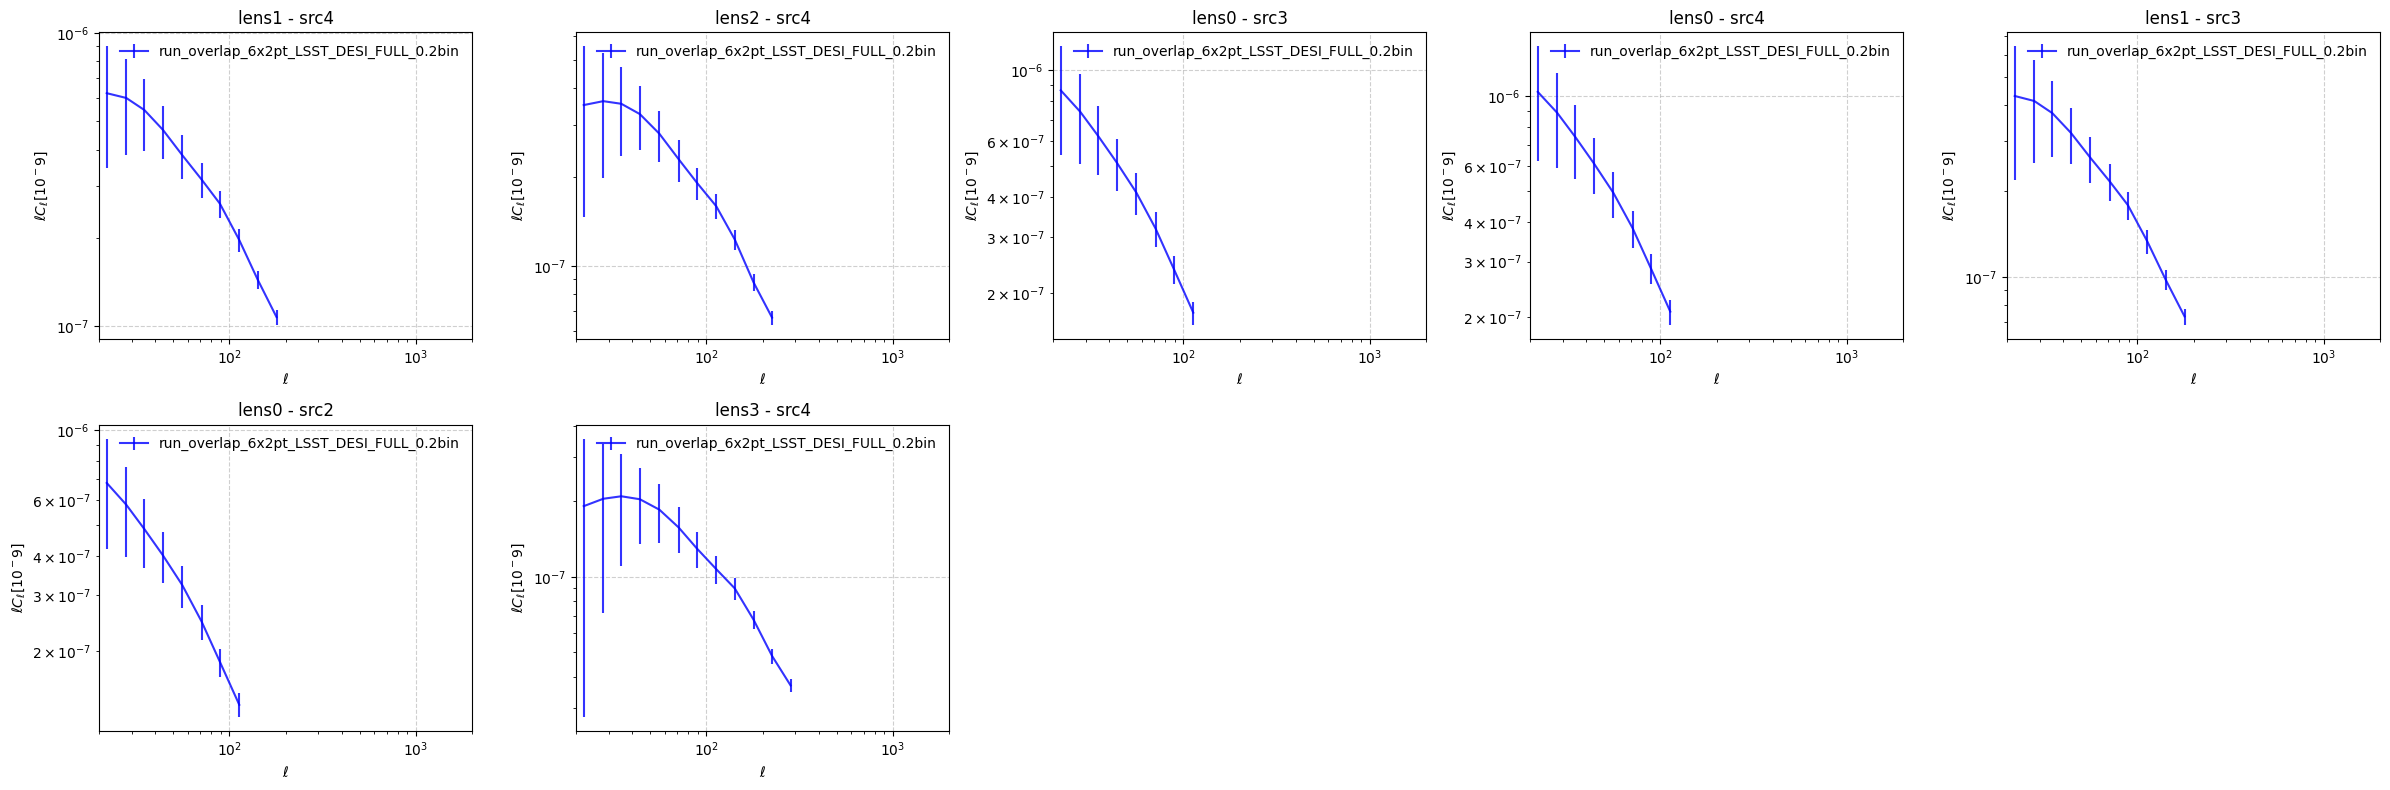

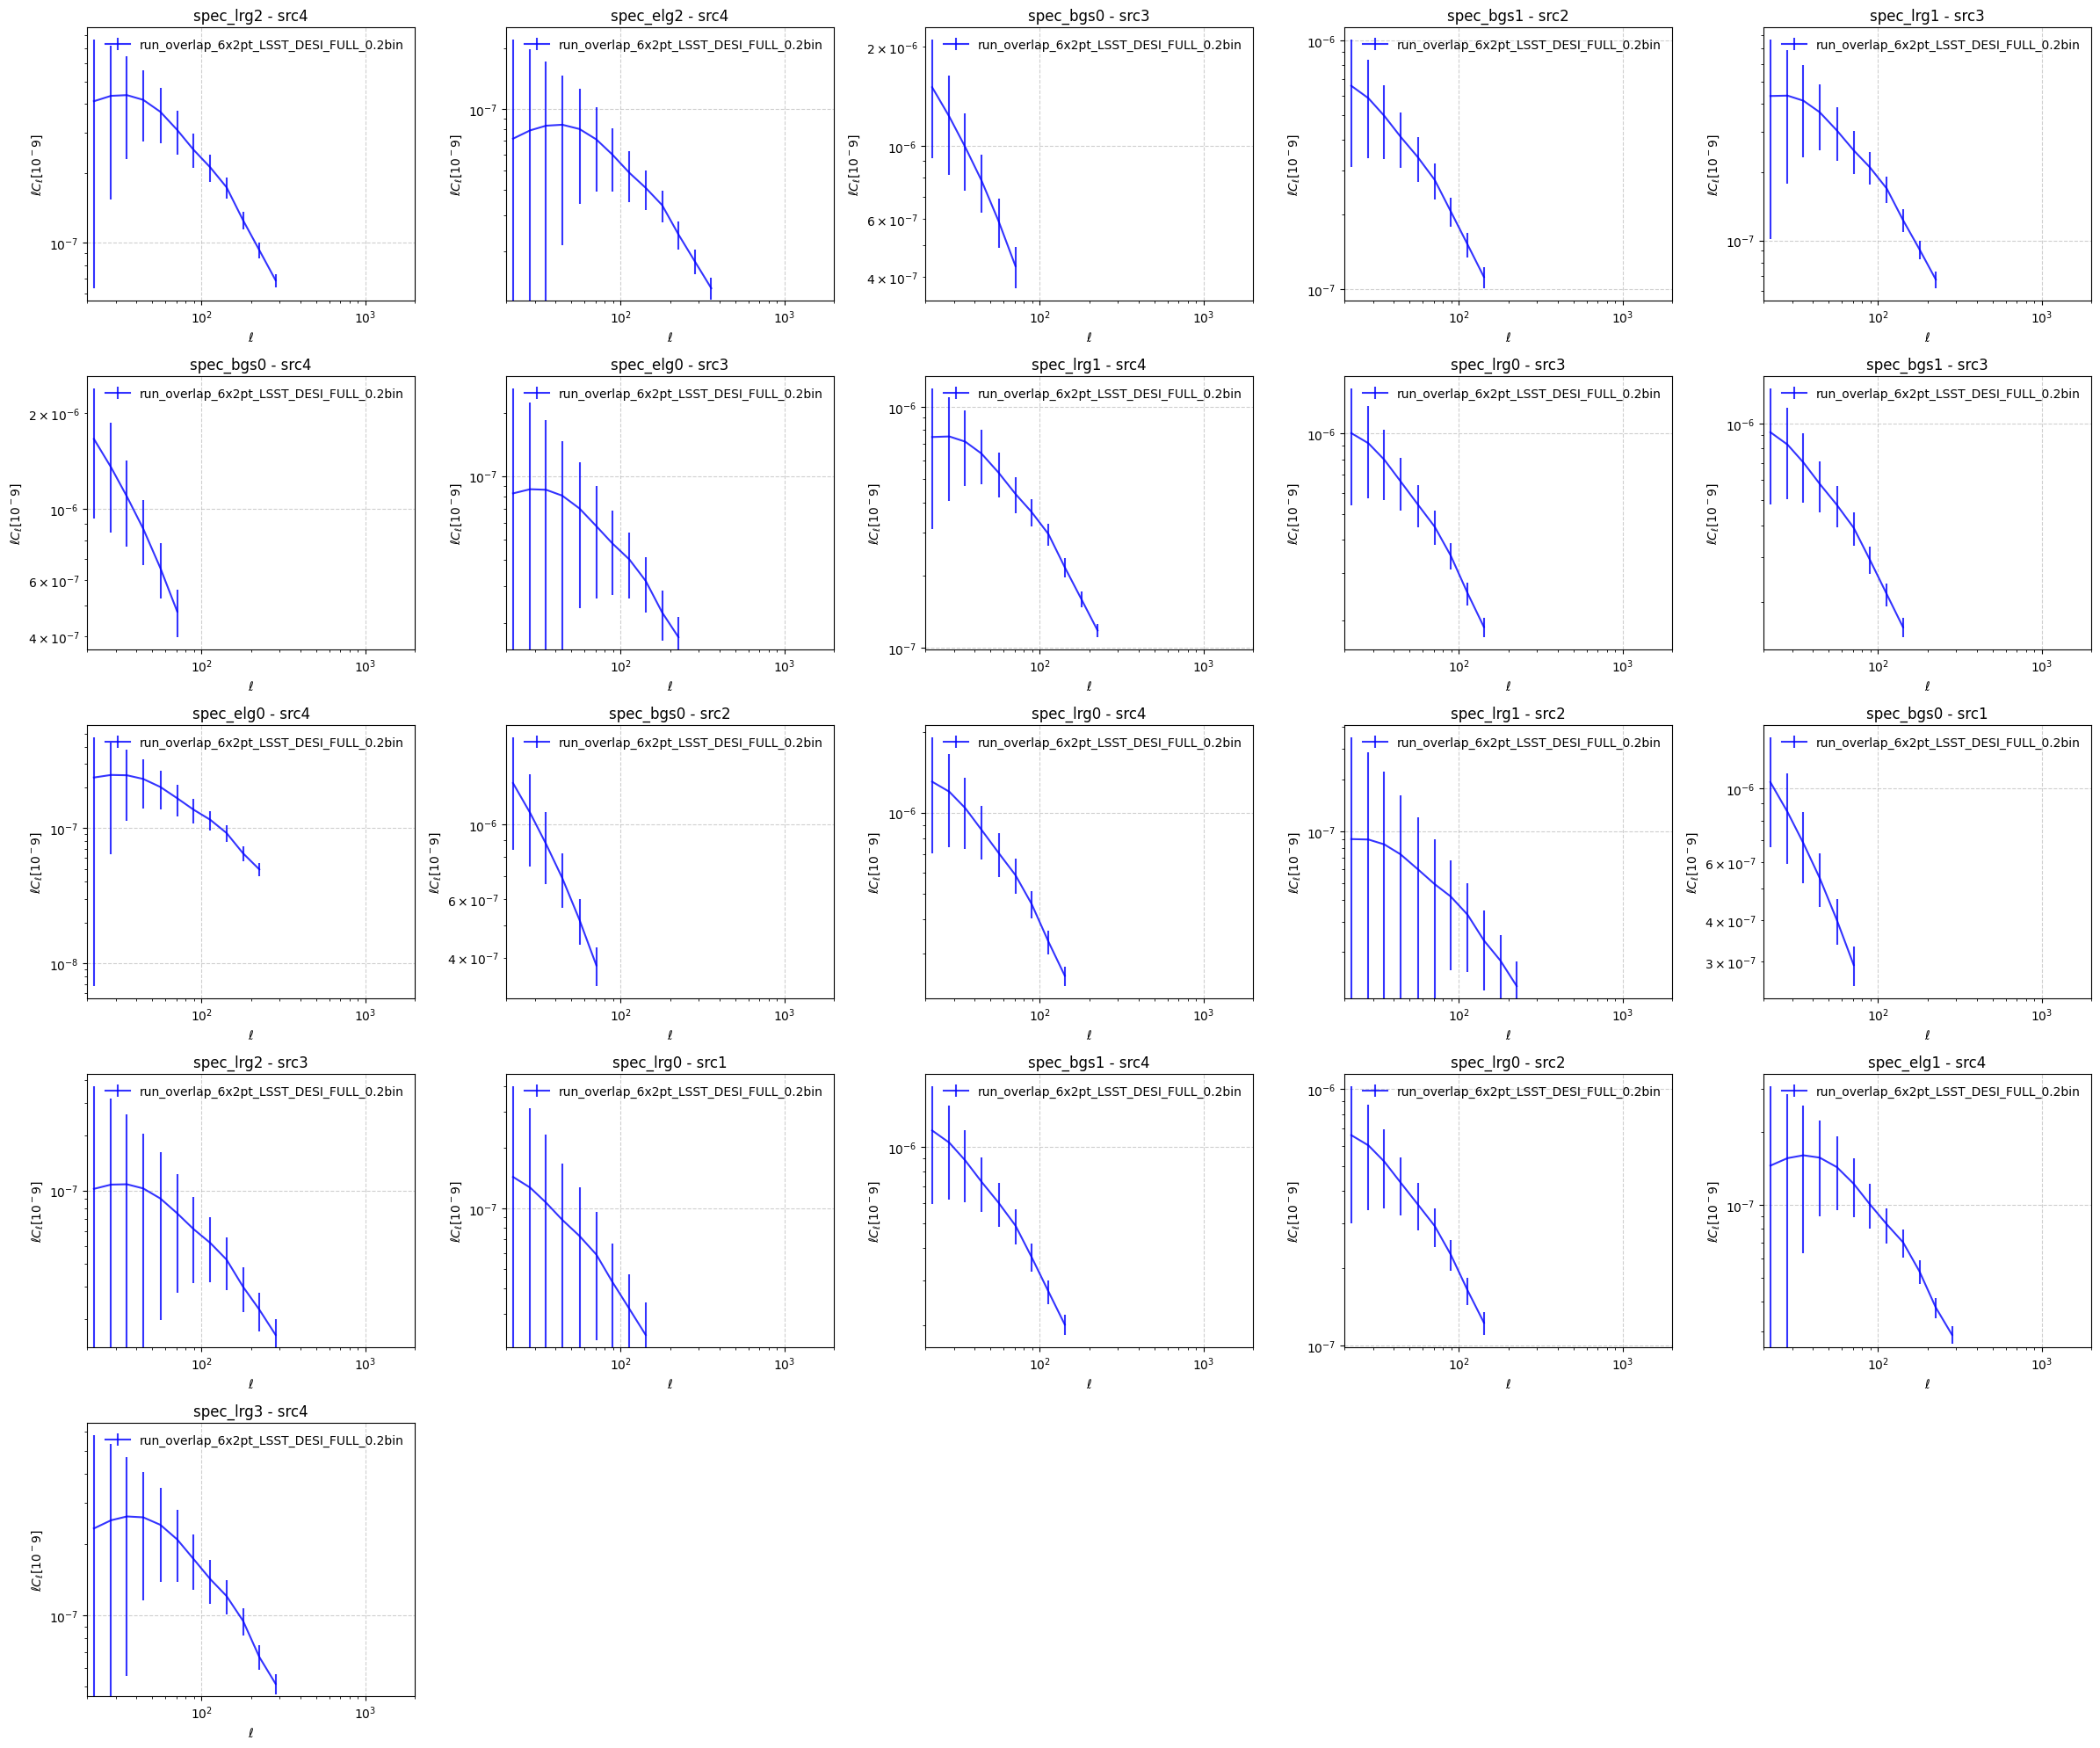

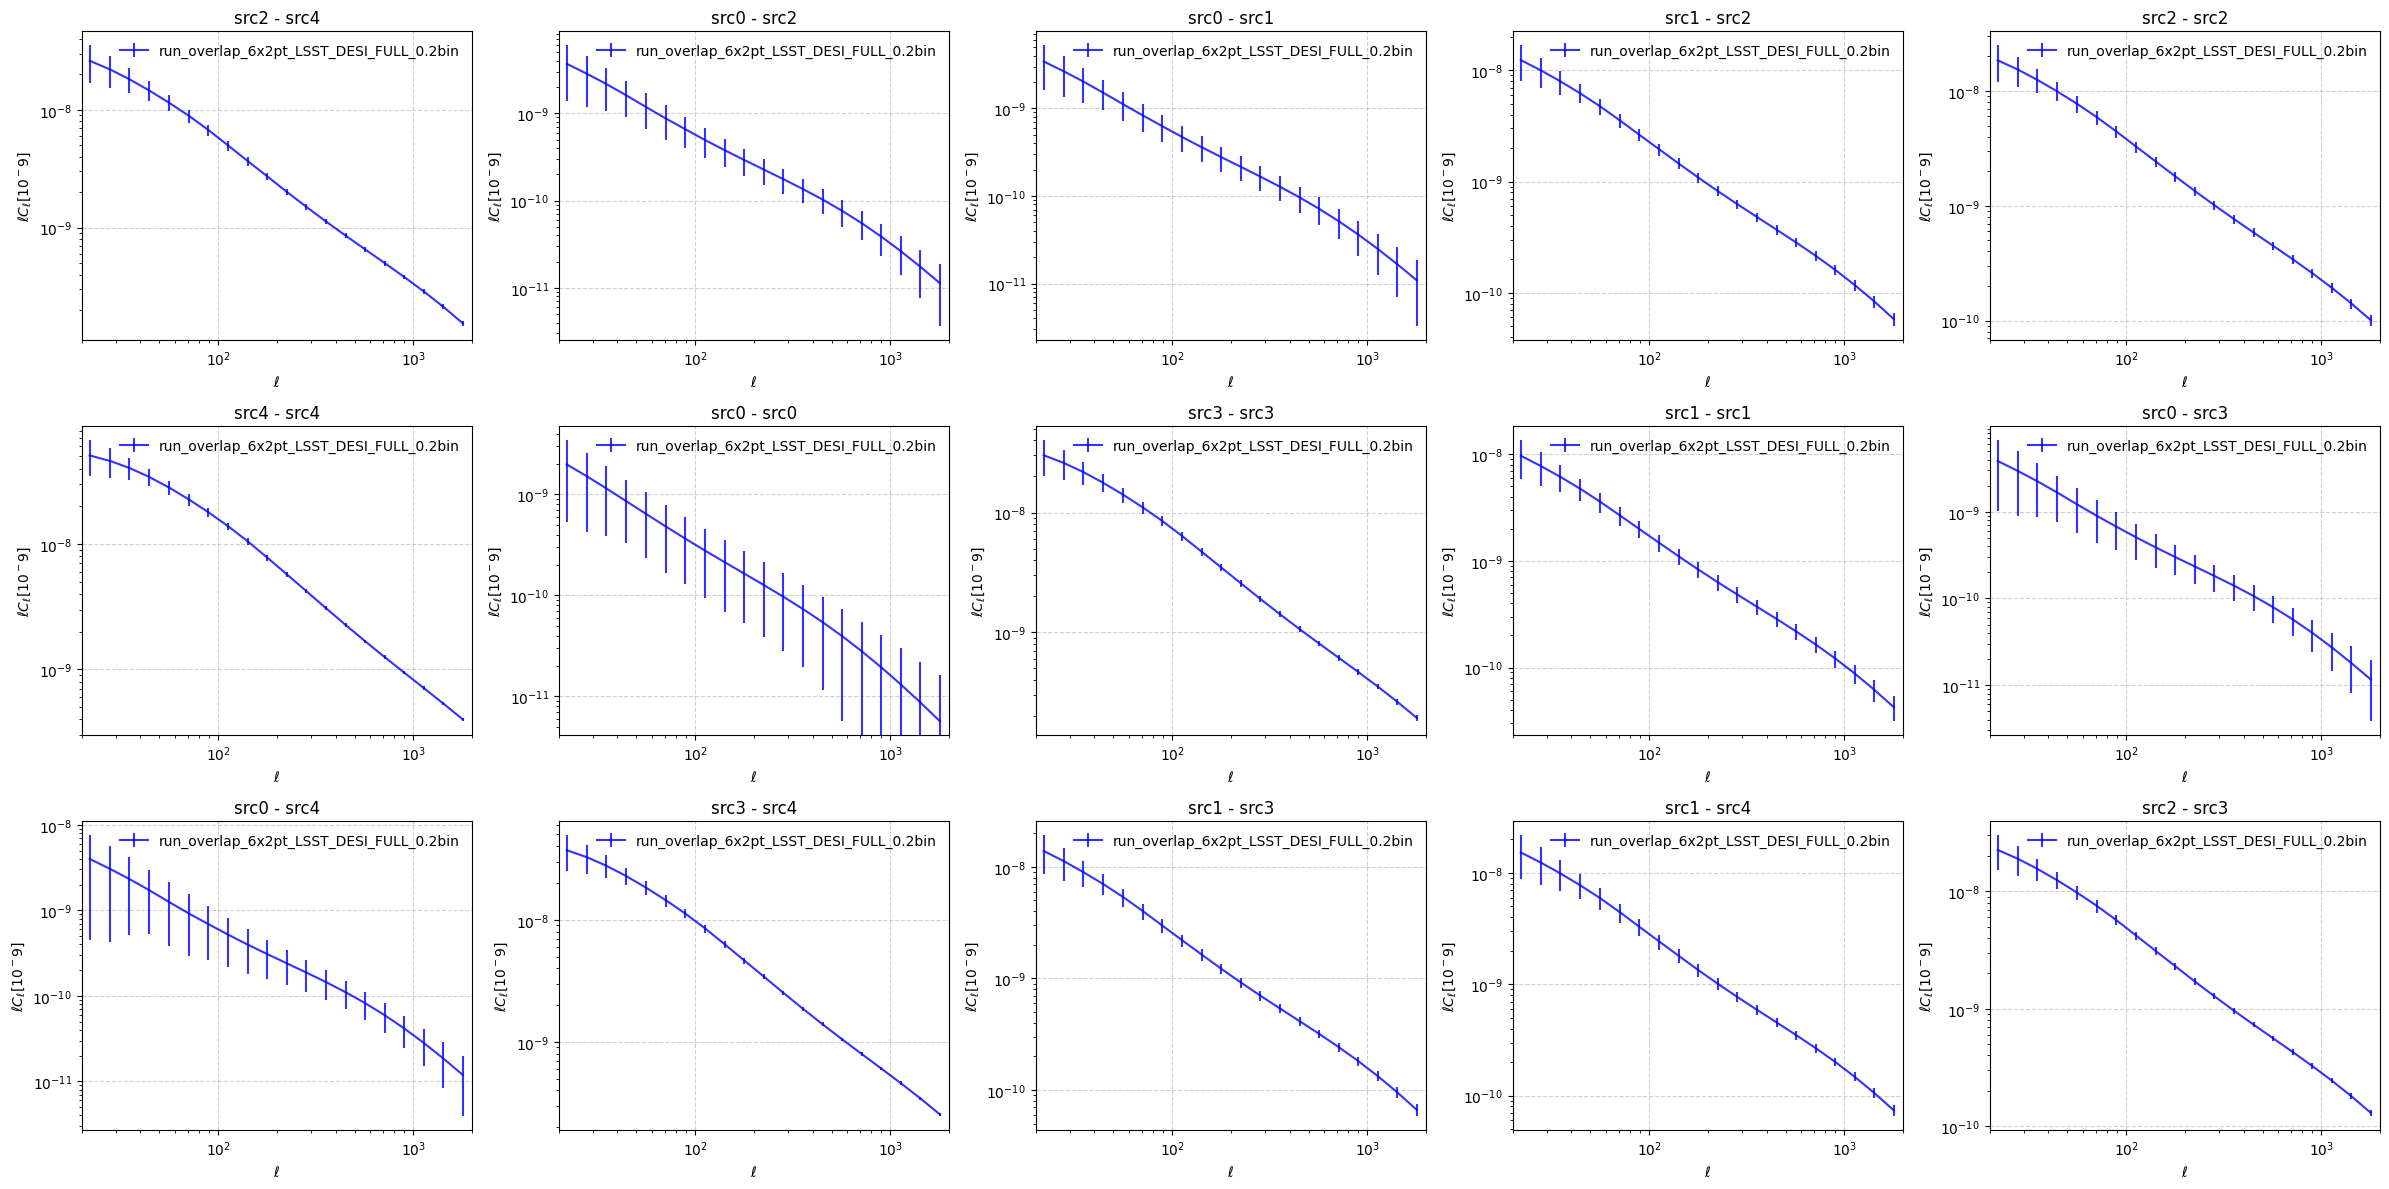

Indices for ('lens0', 'lens0'): [0 1 2 3 4 5 6 7]
Indices for ('lens1', 'lens1'): [ 8  9 10 11 12 13 14 15 16 17]
Indices for ('lens2', 'lens2'): [18 19 20 21 22 23 24 25 26 27 28]
Indices for ('lens3', 'lens3'): [29 30 31 32 33 34 35 36 37 38 39 40]
Indices for ('lens4', 'lens4'): [41 42 43 44 45 46 47 48 49 50 51 52 53]
Indices for ('spec_bgs0', 'lens0'): [54 55 56 57 58 59]
Indices for ('spec_bgs0', 'spec_bgs0'): [60 61 62 63 64 65]
Indices for ('spec_bgs1', 'lens0'): [66 67 68 69 70 71 72 73 74]
Indices for ('spec_bgs1', 'lens1'): [75 76 77 78 79 80 81 82 83]
Indices for ('spec_bgs1', 'spec_bgs1'): [84 85 86 87 88 89 90 91 92]
Indices for ('spec_bgs1', 'spec_lrg0'): [ 93  94  95  96  97  98  99 100 101]
Indices for ('spec_elg0', 'lens1'): [102 103 104 105 106 107 108 109 110 111 112]
Indices for ('spec_elg0', 'lens2'): [113 114 115 116 117 118 119 120 121 122 123]
Indices for ('spec_elg0', 'lens3'): [124 125 126 127 128 129 130 131 132 133 134]
Indices for ('spec_elg0', 'spec_elg0'

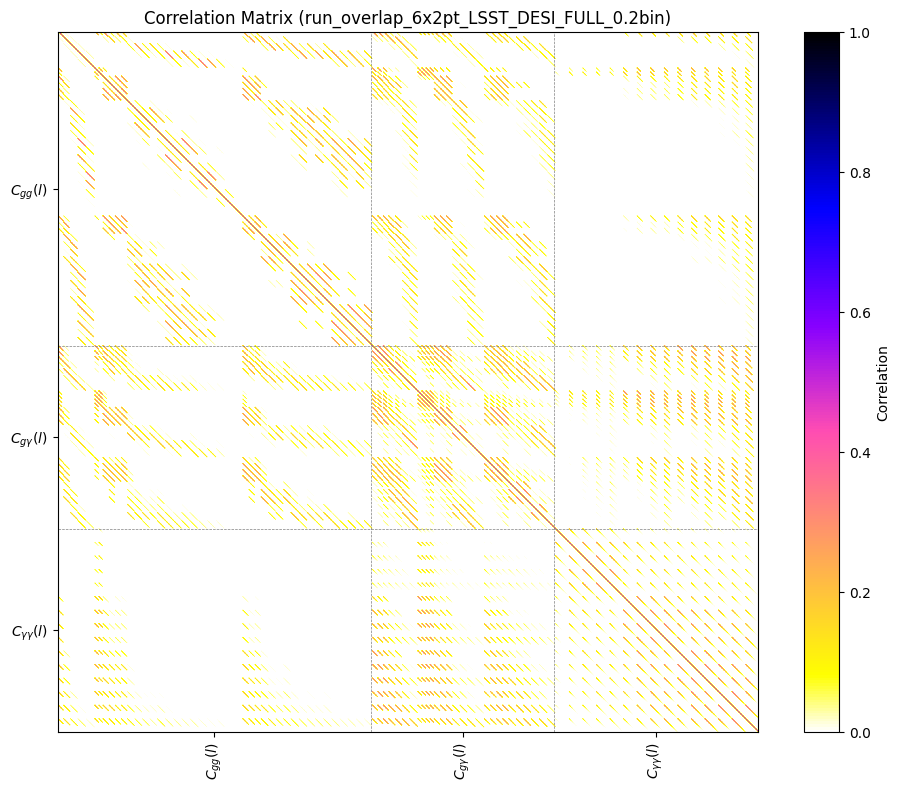

In [24]:
# all this functions just support plot4 runs

# get_sacc_plots(['run_overlapdesi_3x2pt_LSST', 'run_overlap_6x2pt_LSST_DESI_BGS_0.2bin', 'run_overlap_6x2pt_LSST_DESI_LRG_0.2bin', 'run_overlap_6x2pt_LSST_DESI_ELG_0.2bin'])
# get_sacc_plots(['run_overlap_6x2pt_LSST_DESI_FULL_0.2bin', 'run_overlapnorsd_6x2pt_LSST_DESI_FULL_0.2bin'])
get_sacc_plots(['run_overlap_6x2pt_LSST_DESI_FULL_0.2bin'])

In [29]:
def read_augurs_output(analysis_, _run_name_):
    run_name_split = _run_name_.split('_')
    run_name_directory = '_'.join(run_name_split[2:])
    
    print(f"Reading data for run {run_name_directory}...")
    fisher_output_path = f"../runs/{run_name_directory}/fisher_output/{analysis_}"
    bias_values = None

    # Read bias.dat if it exists
    try:
        with open(f'{fisher_output_path}/bias.dat', "r") as f:
            lines = f.readlines()
            if len(lines) > 1:  # Ensure there are at least two lines
                bias_values = np.array(lines[1].strip().split(), dtype=float)
    except FileNotFoundError:
        print(f"Warning: bias.dat not found for run {_run_name_}.")
    except Exception as e:
        print(f"Error reading bias.dat for run {_run_name_}: {e}")

    # Read fiducials.dat
    values_params = []
    parameter_names = []
    try:
        with open(f'{fisher_output_path}/fiducials.dat', "r") as f:
            lines = f.readlines()
            if len(lines) >= 2:  # Ensure there are at least two lines
                # First line contains parameter names
                parameter_names = lines[0].strip().split()
                # Second line contains parameter values
                values_params = [float(val) for val in lines[1].strip().split()]
    except FileNotFoundError:
        raise FileNotFoundError(f"fiducials.dat not found for run {_run_name_}.")
    except Exception as e:
        raise Exception(f"Error reading fiducials.dat for run {_run_name_}: {e}")

    # Read fisher.dat
    try:
        fisher = np.loadtxt(f'{fisher_output_path}/fisher.dat.with_priors')
    except FileNotFoundError:
        raise FileNotFoundError(f"fisher.dat not found for run {_run_name_}.")
    except Exception as e:
        raise Exception(f"Error reading fisher.dat for run {_run_name_}: {e}")

    # Convert to DataFrames
    values_params = np.array(values_params)
    values_bias_params = values_params + bias_values if bias_values is not None else values_params
    fisher_pd = pd.DataFrame(fisher, columns=parameter_names, index=parameter_names)
    
    values_bias_params = pd.DataFrame(values_bias_params, index=parameter_names)
    values_params = pd.DataFrame(values_params, index=parameter_names)

    return parameter_names, values_params, values_bias_params, fisher_pd

def filter_augur_output(parameter_names, values_params, values_bias_params, fisher_pd):
    list_of_parameters_filt = {
    'Omega_c': r'$\Omega_c$',
    'Omega_b': r'$\Omega_b$',
    'h': r'$h$',
    'sigma8': r'$\sigma_8$',
    'n_s': r'$n_s$',
    'w0': r'$w_0$',
    'wa': r'$w_a$',
    'm_nu': r'$\sum m_\nu$',
    'alphaz': r'$\eta_{IA}$',
    'ia_bias': r'$A_{IA}$',
    'lens0_delta_z': r'$\Delta z_{lens0}$',
    'lens1_delta_z': r'$\Delta z_{lens1}$',
    'lens2_delta_z': r'$\Delta z_{lens2}$',
    'lens3_delta_z': r'$\Delta z_{lens3}$',
    'lens4_delta_z': r'$\Delta z_{lens4}$',
    'lens0_sigma_z': r'$\sigma_{z,lens0}$',
    'lens1_sigma_z': r'$\sigma_{z,lens1}$',
    'lens2_sigma_z': r'$\sigma_{z,lens2}$',
    'lens3_sigma_z': r'$\sigma_{z,lens3}$',
    'lens4_sigma_z': r'$\sigma_{z,lens4}$',
    'lens0_bias': r'$b_{lens0}$',
    'lens1_bias': r'$b_{lens1}$',
    'lens2_bias': r'$b_{lens2}$',
    'lens3_bias': r'$b_{lens3}$',
    'lens4_bias': r'$b_{lens4}$',   
    'src0_delta_z': r'$\Delta z_{src0}$',
    'src1_delta_z': r'$\Delta z_{src1}$',
    'src2_delta_z': r'$\Delta z_{src2}$',
    'src3_delta_z': r'$\Delta z_{src3}$',
    'src4_delta_z': r'$\Delta z_{src4}$',
    'src0_sigma_z': r'$\sigma_{z,src0}$',
    'src1_sigma_z': r'$\sigma_{z,src1}$',
    'src2_sigma_z': r'$\sigma_{z,src2}$',
    'src3_sigma_z': r'$\sigma_{z,src3}$',
    'src4_sigma_z': r'$\sigma_{z,src4}$',
    }
    # Filter the parameters
    print(f"Filtered parameters: {parameter_names}")
    filtered_values_params = values_params.loc[parameter_names]
    filtered_values_bias_params = values_bias_params.loc[parameter_names]
    inv_fisher = np.linalg.inv(fisher_pd)
    inv_fisher_pd = pd.DataFrame(inv_fisher, columns=fisher_pd.columns, index=fisher_pd.index)
    filtered_inv_fisher_pd = inv_fisher_pd.loc[parameter_names, parameter_names]
    # Rename the parameters
    filtered_parameter_names = [list_of_parameters_filt[name] for name in parameter_names]
    return filtered_parameter_names, filtered_values_params, filtered_values_bias_params, filtered_inv_fisher_pd

Reading data for run 3x2pt_LSST...
Filtered parameters: ['Omega_c', 'sigma8', 'n_s', 'Omega_b', 'h', 'm_nu']
Reading data for run 3x2pt_LSST...
Filtered parameters: ['Omega_c', 'sigma8', 'n_s', 'Omega_b', 'h', 'm_nu']
Reading data for run 6x2pt_LSST_DESI_FULL_0.2bin...
Filtered parameters: ['Omega_c', 'sigma8', 'n_s', 'Omega_b', 'h', 'm_nu']


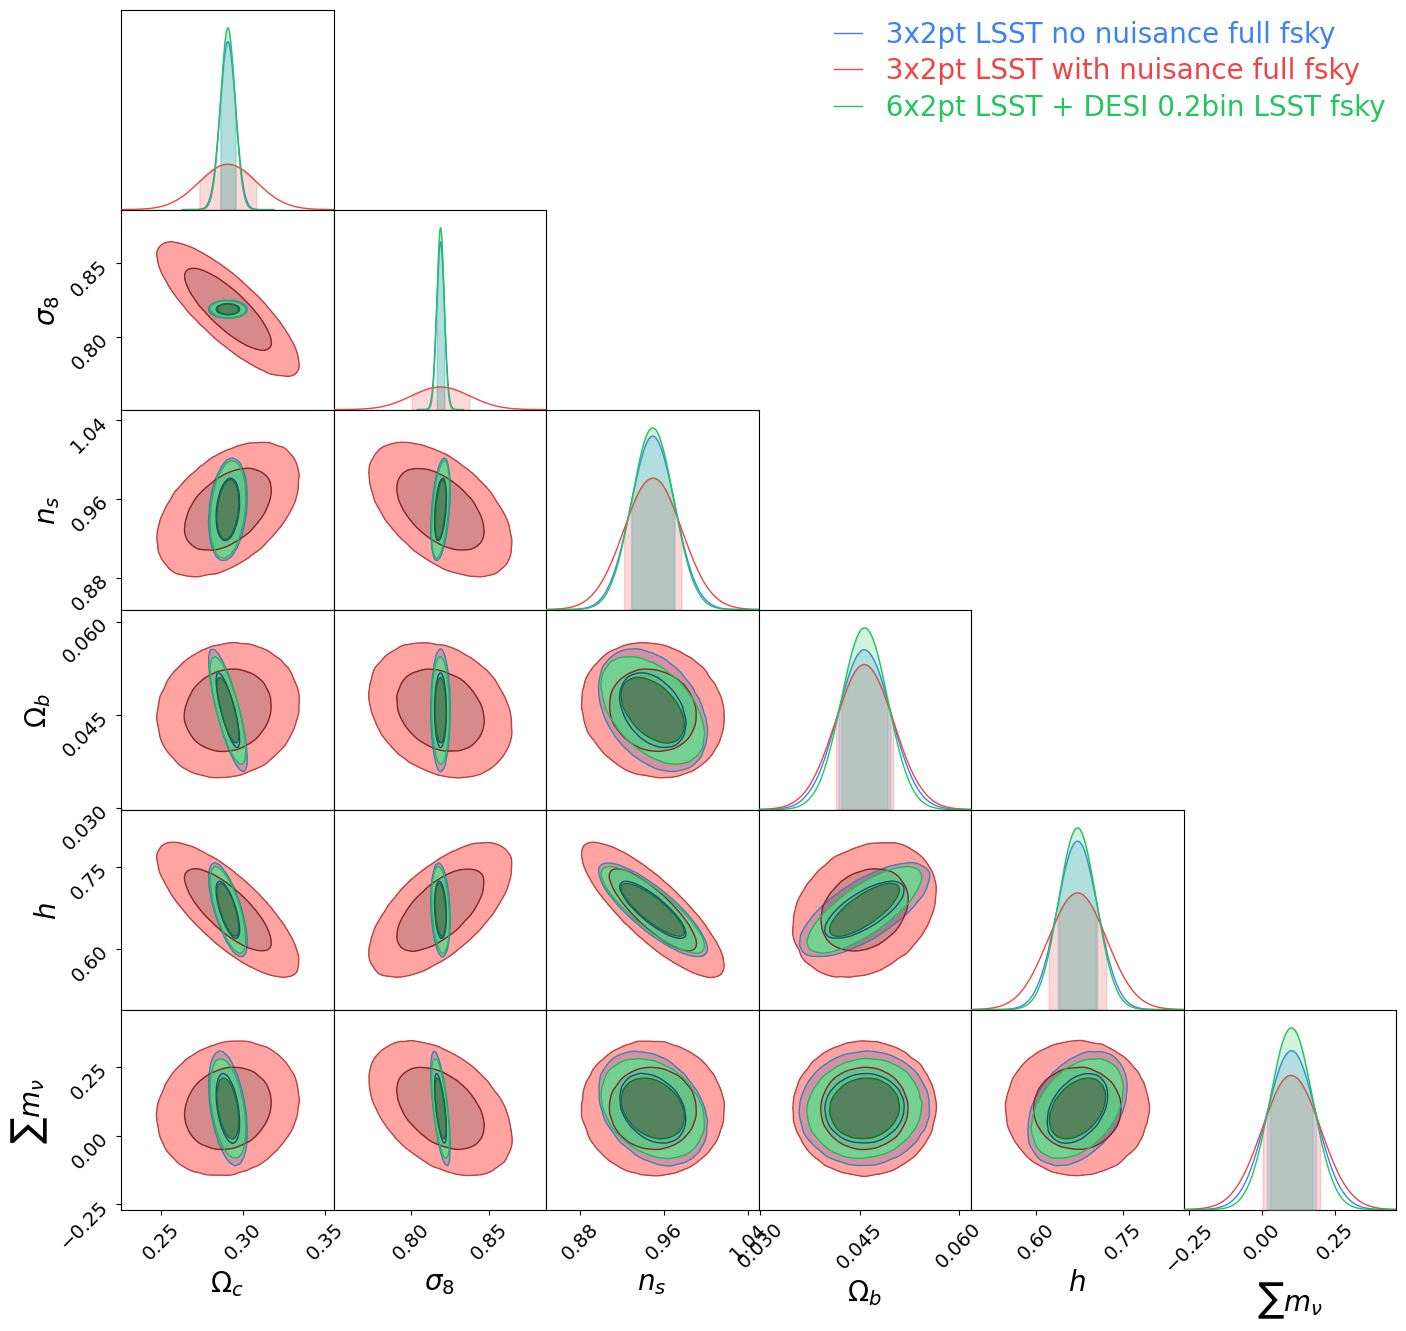

In [30]:

# Create a ChainConsumer instance
param_names = ['Omega_c', 'sigma8', 'n_s', 'Omega_b', 'h']
# param_names = ['Omega_c', 'sigma8', 'n_s', 'Omega_b', 'h', 'w0', 'wa']
# param_names = ['Omega_c', 'sigma8', 'n_s', 'Omega_b', 'h', 'm_nu']
# param_names = ['Omega_c', 'sigma8', 'n_s', 'Omega_b', 'h', 'w0', 'wa', 'm_nu']
# param_names = ['alphaz', 'ia_bias']
# param_names = ['lens0_bias', 'lens1_bias', 'lens2_bias', 'lens3_bias', 'lens4_bias']
# param_names = ['lens0_delta_z', 'lens1_delta_z', 'lens2_delta_z', 'lens3_delta_z', 'lens4_delta_z', 'lens0_sigma_z', 'lens1_sigma_z', 'lens2_sigma_z', 'lens3_sigma_z', 'lens4_sigma_z']
# param_names = ['src0_delta_z', 'src1_delta_z', 'src2_delta_z', 'src3_delta_z', 'src4_delta_z', 'src0_sigma_z', 'src1_sigma_z', 'src2_sigma_z', 'src3_sigma_z', 'src4_sigma_z']

# param_names = ['w0', 'wa', 'lens0_bias', 'lens1_bias', 'lens2_bias', 'lens3_bias', 'lens4_bias', 'lens0_delta_z', 'lens1_delta_z', 'lens2_delta_z', 'lens3_delta_z', 'lens4_delta_z', 'ia_bias', 'alphaz' ]
# param_names = [ 'ia_bias', 'alphaz', 'src0_delta_z', 'src1_delta_z', 'src2_delta_z', 'src3_delta_z', 'src4_delta_z', 'src0_sigma_z', 'src1_sigma_z', 'src2_sigma_z', 'src3_sigma_z', 'src4_sigma_z']
# param_names = ['lens0_bias', 'lens1_bias', 'lens2_bias', 'lens3_bias', 'lens4_bias', 'lens0_delta_z', 'lens1_delta_z', 'lens2_delta_z', 'lens3_delta_z', 'lens4_delta_z', 'lens0_sigma_z', 'lens1_sigma_z', 'lens2_sigma_z', 'lens3_sigma_z', 'lens4_sigma_z']
c = ChainConsumer()
# param_names = ['Omega_c', 'sigma8', 'n_s', 'Omega_b', 'h', 'lens0_delta_z', 'lens1_delta_z', 'lens2_delta_z', 'lens3_delta_z', 'lens4_delta_z', 'lens0_sigma_z', 'lens1_sigma_z', 'lens2_sigma_z', 'lens3_sigma_z', 'lens4_sigma_z', 'lens0_bias', 'lens1_bias', 'lens2_bias', 'lens3_bias', 'lens4_bias', 'src0_delta_z', 'src1_delta_z', 'src2_delta_z', 'src3_delta_z', 'src4_delta_z', 'src0_sigma_z', 'src1_sigma_z', 'src2_sigma_z', 'src3_sigma_z', 'src4_sigma_z', 'ia_bias', 'alphaz']


param_names, values_params1, values_bias_params1, fisher_pd1 = read_augurs_output('base/LCDM_mnu_no_nuisance', 'run_base_3x2pt_LSST')
param_names1, values_params1, values_bias_params1, inv_fisher_pd1 = filter_augur_output(param_names, values_params1, values_bias_params1, fisher_pd1)
c.add_chain(
        Chain.from_covariance(mean=values_params1.to_numpy().flatten(),
                              covariance=inv_fisher_pd1.values, 
                              columns=param_names1, 
                              name="3x2pt LSST no nuisance full fsky",
                              color='blue', 
                            ))

# param_names = [ 'm_nu', 'lens0_bias', 'lens1_bias', 'lens2_bias', 'lens3_bias', 'lens4_bias']
# param_names = ['Omega_c', 'sigma8', 'n_s', 'Omega_b', 'h', 'lens0_delta_z', 'lens1_delta_z', 'lens2_delta_z', 'lens3_delta_z', 'lens4_delta_z', 'lens0_sigma_z', 'lens1_sigma_z', 'lens2_sigma_z', 'lens3_sigma_z', 'lens4_sigma_z', 'lens0_bias', 'lens1_bias', 'lens2_bias', 'lens3_bias', 'lens4_bias', 'src0_delta_z', 'src1_delta_z', 'src2_delta_z', 'src3_delta_z', 'src4_delta_z', 'src0_sigma_z', 'src1_sigma_z', 'src2_sigma_z', 'src3_sigma_z', 'src4_sigma_z', 'ia_bias', 'alphaz']
# param_names = ['lens0_delta_z', 'lens1_delta_z', 'lens2_delta_z', 'lens3_delta_z', 'lens4_delta_z', 'lens0_sigma_z', 'lens1_sigma_z', 'lens2_sigma_z', 'lens3_sigma_z', 'lens4_sigma_z', 'lens0_bias', 'lens1_bias', 'lens2_bias', 'lens3_bias', 'lens4_bias']
# param_names = ['src0_delta_z', 'src1_delta_z', 'src2_delta_z', 'src3_delta_z', 'src4_delta_z', 'src0_sigma_z', 'src1_sigma_z', 'src2_sigma_z', 'src3_sigma_z', 'src4_sigma_z', 'ia_bias', 'alphaz']


param_names_, values_params1, values_bias_params1, fisher_pd1 = read_augurs_output('base/LCDM_mnu', 'run_base_3x2pt_LSST')
param_names1, values_params1, values_bias_params1, inv_fisher_pd1 = filter_augur_output(param_names, values_params1, values_bias_params1, fisher_pd1)
c.add_chain(
        Chain.from_covariance(mean=values_params1.to_numpy().flatten(),
                              covariance=inv_fisher_pd1.values, 
                              columns=param_names1, 
                              name="3x2pt LSST with nuisance full fsky",
                              color='red', 
                            ))

param_names_, values_params1, values_bias_params1, fisher_pd1 = read_augurs_output('overlap18k/LCDM_mnu', 'run_overlap18k_6x2pt_LSST_DESI_FULL_0.2bin')
param_names1, values_params1, values_bias_params1, inv_fisher_pd1 = filter_augur_output(param_names, values_params1, values_bias_params1, fisher_pd1)
c.add_chain(
        Chain.from_covariance(mean=values_params1.to_numpy().flatten(),
                              covariance=inv_fisher_pd1.values, 
                              columns=param_names1, 
                              name="6x2pt LSST + DESI 0.2bin LSST fsky",
                              color='green', 
                            ))




# Set parameter range for a specific parameter
# c.set_plot_config(PlotConfig(extents={r'$\sum m_\nu$': (0.06, 0.5)}))
c.set_plot_config(PlotConfig(max_ticks= 3, label_font_size=20, tick_font_size=14))
fig = c.plotter.plot()


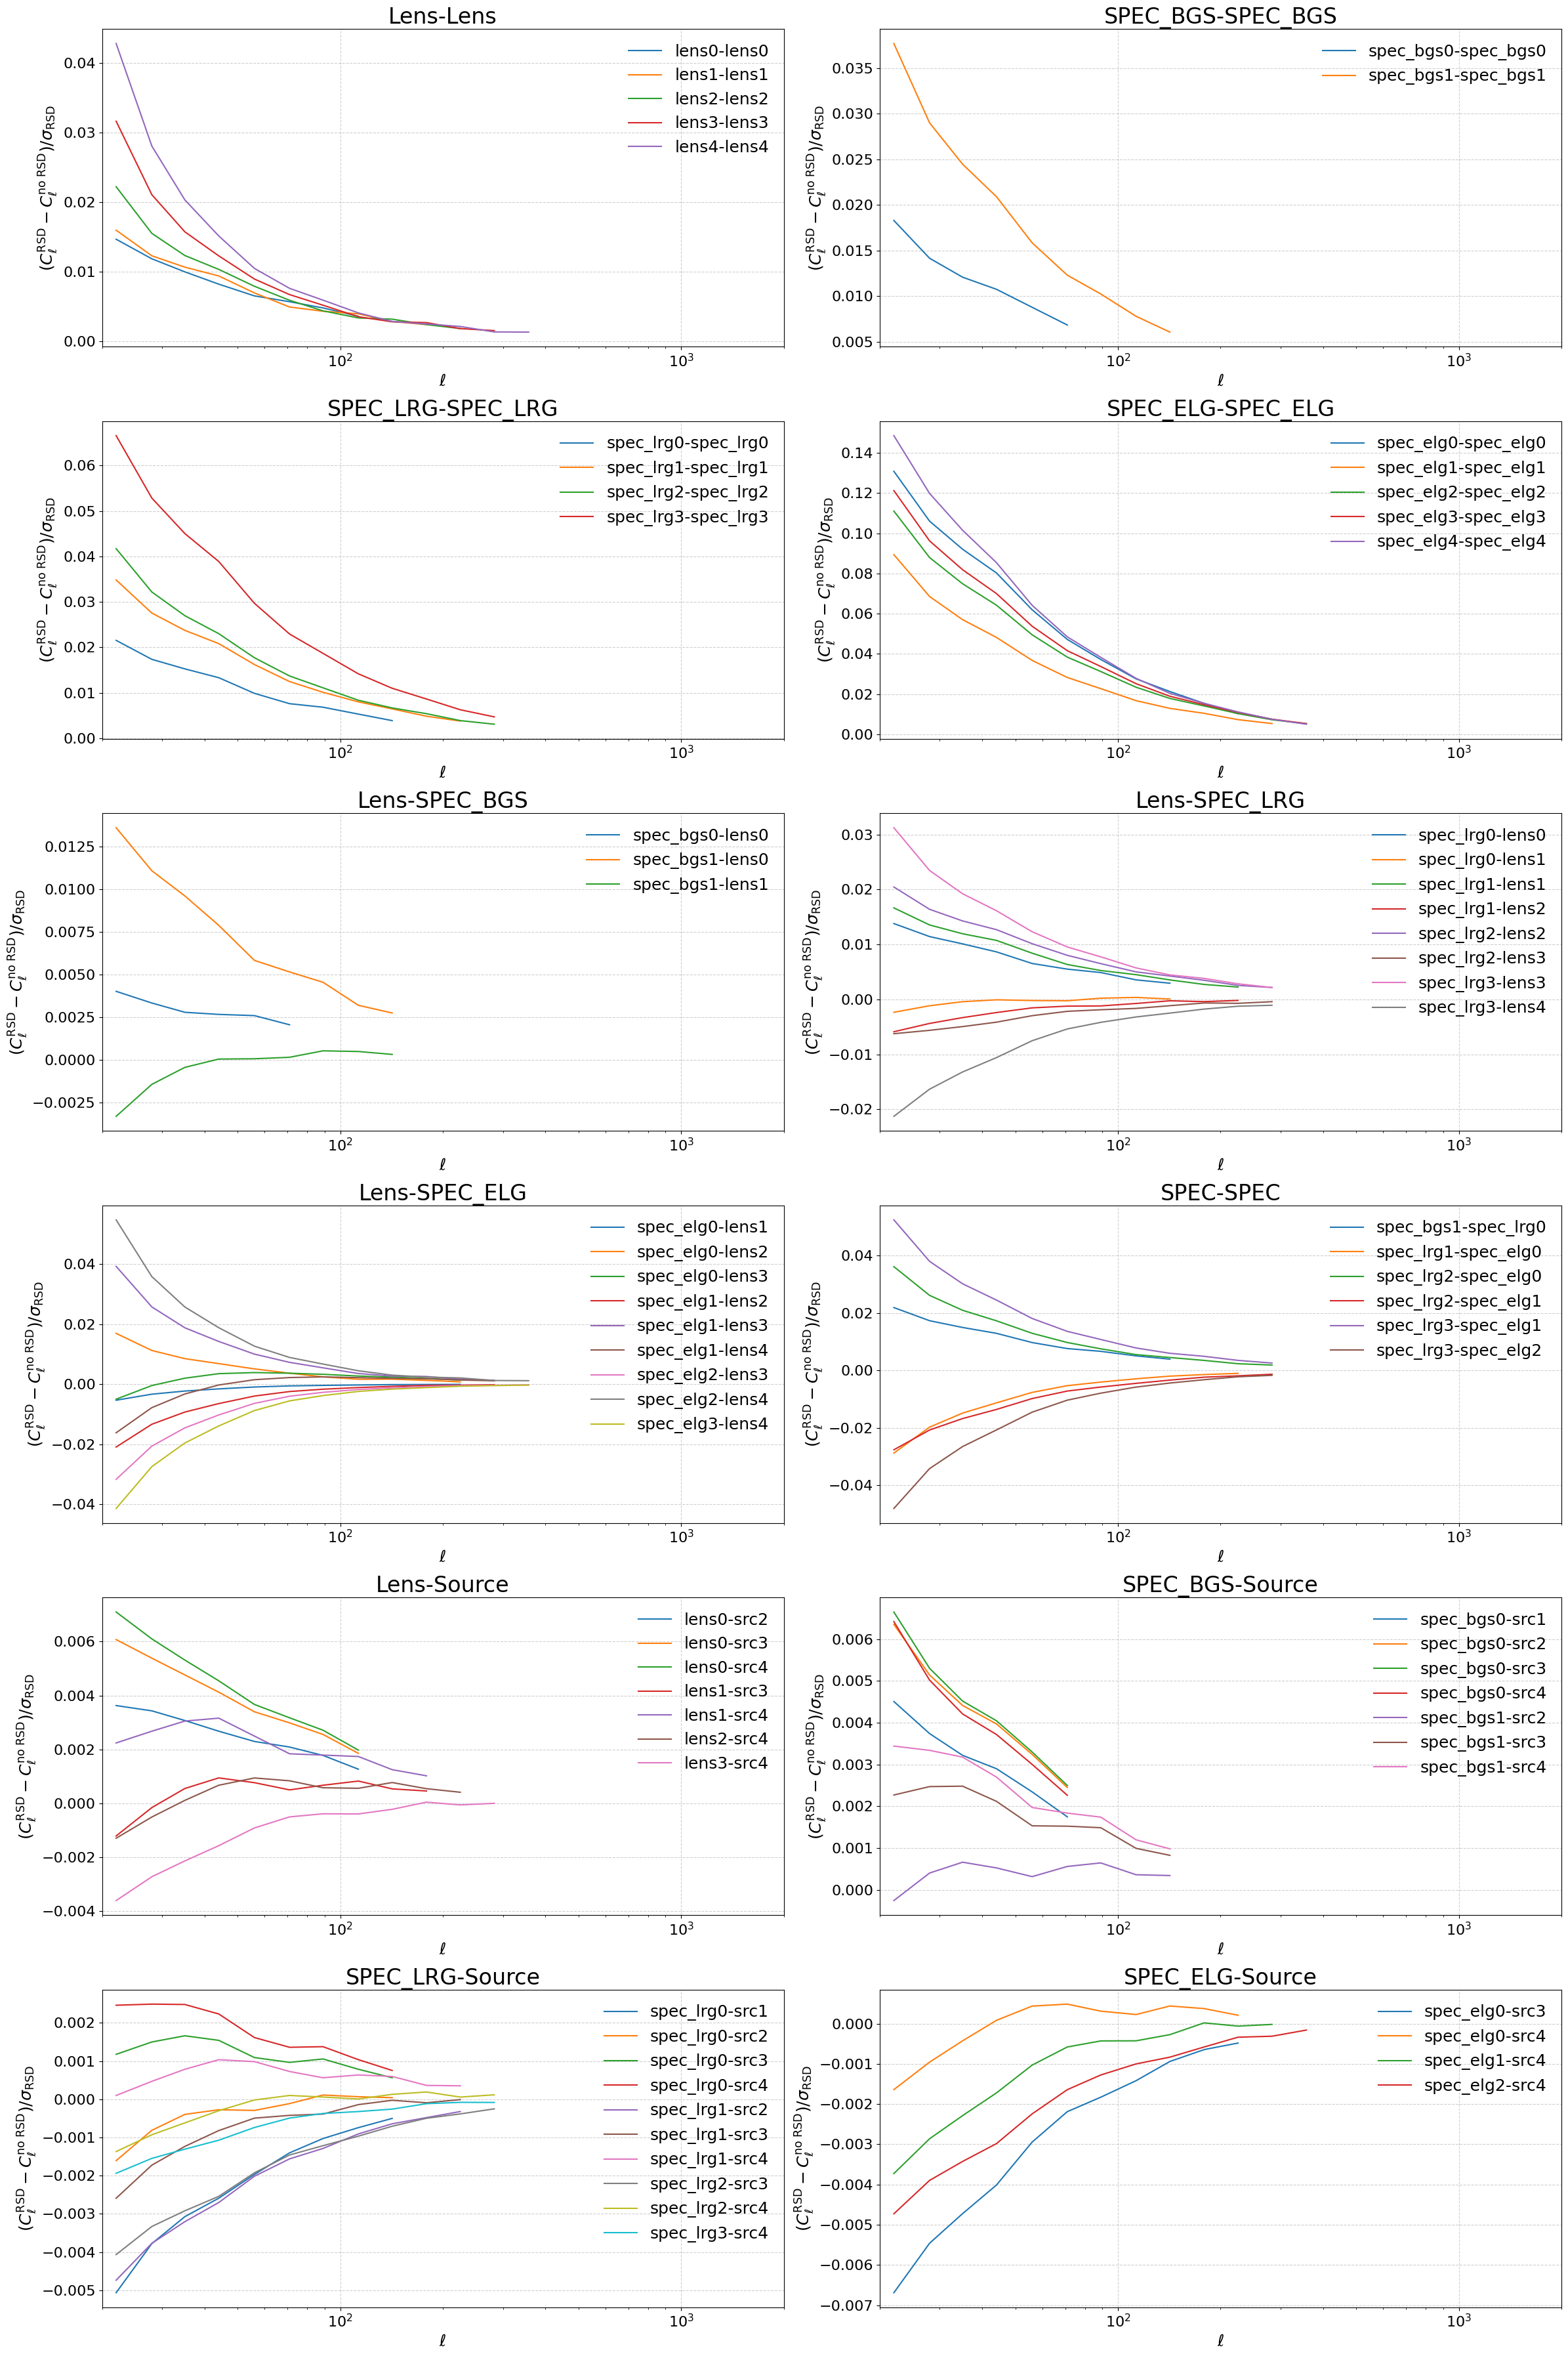

In [31]:
import matplotlib.pyplot as plt
import numpy as np
from itertools import cycle

# Carrega os dados
sacc_data1 = get_6x2pt_sacc(["run_overlap_6x2pt_LSST_DESI_FULL_0.2bin"])[0]
sacc_data2 = get_6x2pt_sacc(["run_overlapnorsd_6x2pt_LSST_DESI_FULL_0.2bin"])[0]

# Combinações de densidade e shearDensity
all_tracer_combinations = sacc_data1.get_tracer_combinations(data_type='galaxy_density_cl')
all_tracer_combinations += sacc_data1.get_tracer_combinations(data_type='galaxy_shearDensity_cl_e')

# Define categorias
categories = {
    "lens-lens": [],
    "spec_bgs-spec_bgs": [],
    "spec_lrg-spec_lrg": [],
    "spec_elg-spec_elg": [],
    "lens-spec_bgs": [],
    "lens-spec_lrg": [],
    "lens-spec_elg": [],
    "spec-mixed": [],
    "lens-src": [],
    "spec_bgs-src": [],
    "spec_lrg-src": [],
    "spec_elg-src": [],
}

for tr1, tr2 in all_tracer_combinations:
    # Primeiro, lens-src
    if (tr1.startswith("lens") and tr2.startswith("src")) or (tr2.startswith("lens") and tr1.startswith("src")):
        categories["lens-src"].append((tr1, tr2))

    # Depois, spec-src detalhado
    elif "src" in tr1 or "src" in tr2:
        spec = tr1 if "src" not in tr1 else tr2
        if "spec_bgs" in spec:
            categories["spec_bgs-src"].append((tr1, tr2))
        elif "spec_lrg" in spec:
            categories["spec_lrg-src"].append((tr1, tr2))
        elif "spec_elg" in spec:
            categories["spec_elg-src"].append((tr1, tr2))

    # Lens-lens
    elif tr1.startswith("lens") and tr2.startswith("lens"):
        categories["lens-lens"].append((tr1, tr2))

    # Spec-spec (mesmo tipo)
    elif tr1.startswith("spec_bgs") and tr2.startswith("spec_bgs"):
        categories["spec_bgs-spec_bgs"].append((tr1, tr2))
    elif tr1.startswith("spec_lrg") and tr2.startswith("spec_lrg"):
        categories["spec_lrg-spec_lrg"].append((tr1, tr2))
    elif tr1.startswith("spec_elg") and tr2.startswith("spec_elg"):
        categories["spec_elg-spec_elg"].append((tr1, tr2))

    # Lens-spec (separado por tipo)
    elif (tr1.startswith("lens") and tr2.startswith("spec")) or (tr2.startswith("lens") and tr1.startswith("spec")):
        spec = tr1 if tr1.startswith("spec") else tr2
        if "spec_bgs" in spec:
            categories["lens-spec_bgs"].append((tr1, tr2))
        elif "spec_lrg" in spec:
            categories["lens-spec_lrg"].append((tr1, tr2))
        elif "spec_elg" in spec:
            categories["lens-spec_elg"].append((tr1, tr2))

    # Spec-spec misto
    elif (
        ("spec_bgs" in tr1 and "spec_lrg" in tr2) or
        ("spec_lrg" in tr1 and "spec_elg" in tr2) or
        ("spec_lrg" in tr2 and "spec_elg" in tr1) or
        ("spec_bgs" in tr2 and "spec_lrg" in tr1)
    ):
        categories["spec-mixed"].append((tr1, tr2))


# Define ticks para o eixo ℓ
x_ticks = [20, 50, 100, 200, 500, 1000, 2000]

# Cria figura com 10 subplots
fig, ax = plt.subplots(nrows=6, ncols=2, figsize=(24, 36))
ax = ax.flatten()

# Títulos organizados na mesma ordem dos dicionários
titles = [
    "Lens-Lens",
    "SPEC_BGS-SPEC_BGS",
    "SPEC_LRG-SPEC_LRG",
    "SPEC_ELG-SPEC_ELG",
    "Lens-SPEC_BGS",
    "Lens-SPEC_LRG",
    "Lens-SPEC_ELG",
    "SPEC-SPEC",
    "Lens-Source",
    "SPEC_BGS-Source",
    "SPEC_LRG-Source",
    "SPEC_ELG-Source",
]


ticks_dict = {
    "lens-lens": [0.985, 0.99, 1.0],
    "spec_bgs-spec_bgs": [0.99, 1.0],
    "spec_lrg-spec_lrg": [0.97, 0.98, 0.99, 1.0],
    "spec_elg-spec_elg": [0.94, 0.96, 0.98, 1.0],
    "lens-spec_bgs": [0.995, 1.0],
    "lens-spec_lrg": [0.985, 0.99, 1.0, 1.01],
    "lens-spec_elg": [0.97, 0.98, 0.99, 1.0, 1.01],
    "spec-mixed": [0.97, 0.98, 0.99, 1.0],
    "lens-src": [0.997, 1.0, 1.003],
    "spec_bgs-src": [0.997, 1.0],
    "spec_lrg-src": [0.999, 1.0, 1.015],
    "spec_elg-src": [1.0, 1.015],
}
# Plota cada categoria no subplot correspondente
for idx, (category, combos) in enumerate(categories.items()):
    local_colors = cycle(plt.cm.tab10.colors)  # Reset cores a cada subplot
    for tr1, tr2 in combos:
        color = next(local_colors)

        try:
            # Dados com e sem RSD
            ell, C_ell, cov = sacc_data1.get_ell_cl(None, tr1, tr2, return_cov=True)
            ell2, C_ell2, cov2 = sacc_data2.get_ell_cl(None, tr1, tr2, return_cov=True)

            ratio = (C_ell-C_ell2)/ np.sqrt(np.diag(cov))
            ax[idx].plot(ell, ratio, ls='-', color=color, label=f"{tr1}-{tr2}")
            # Calculate the distance between theory vectors in covariance units
                
            # distance = ((C_ell - C_ell2))/(C_ell)
        
            # Plot the distance as a bar chart
            # ax[idx].plot(ell, distance, color=color, alpha=0.7)

        except Exception as e:
            print(f"Erro em {tr1}-{tr2}: {e}")

    ax[idx].set_title(titles[idx], fontsize=24)
    ax[idx].set_xscale("log")
    # ax[idx].set_yscale("log")
    # ax[idx].hlines(1, 10, 2000, colors='black', linestyles='--', linewidth=1)
    ax[idx].set_xlim(20, 2000)
    ax[idx].set_xlabel("$\ell$", fontsize=18)
    ax[idx].set_ylabel("$(C_\\ell^{\\text{RSD}} - C_\\ell^{\\text{no RSD}})/\sigma_{\\text{RSD}}$", fontsize=18)
    ax[idx].tick_params(labelsize=16)
    # ax[idx].set_xticks(x_ticks)
    # ax[idx].set_yticks(ticks_dict[category])
    # ax[idx].set_xticklabels([f"{x}" for x in x_ticks])
    ax[idx].grid(True, linestyle="--", alpha=0.6)
    ax[idx].legend(fontsize=18, frameon=False, loc="best", ncol=1)

plt.tight_layout()
plt.show()


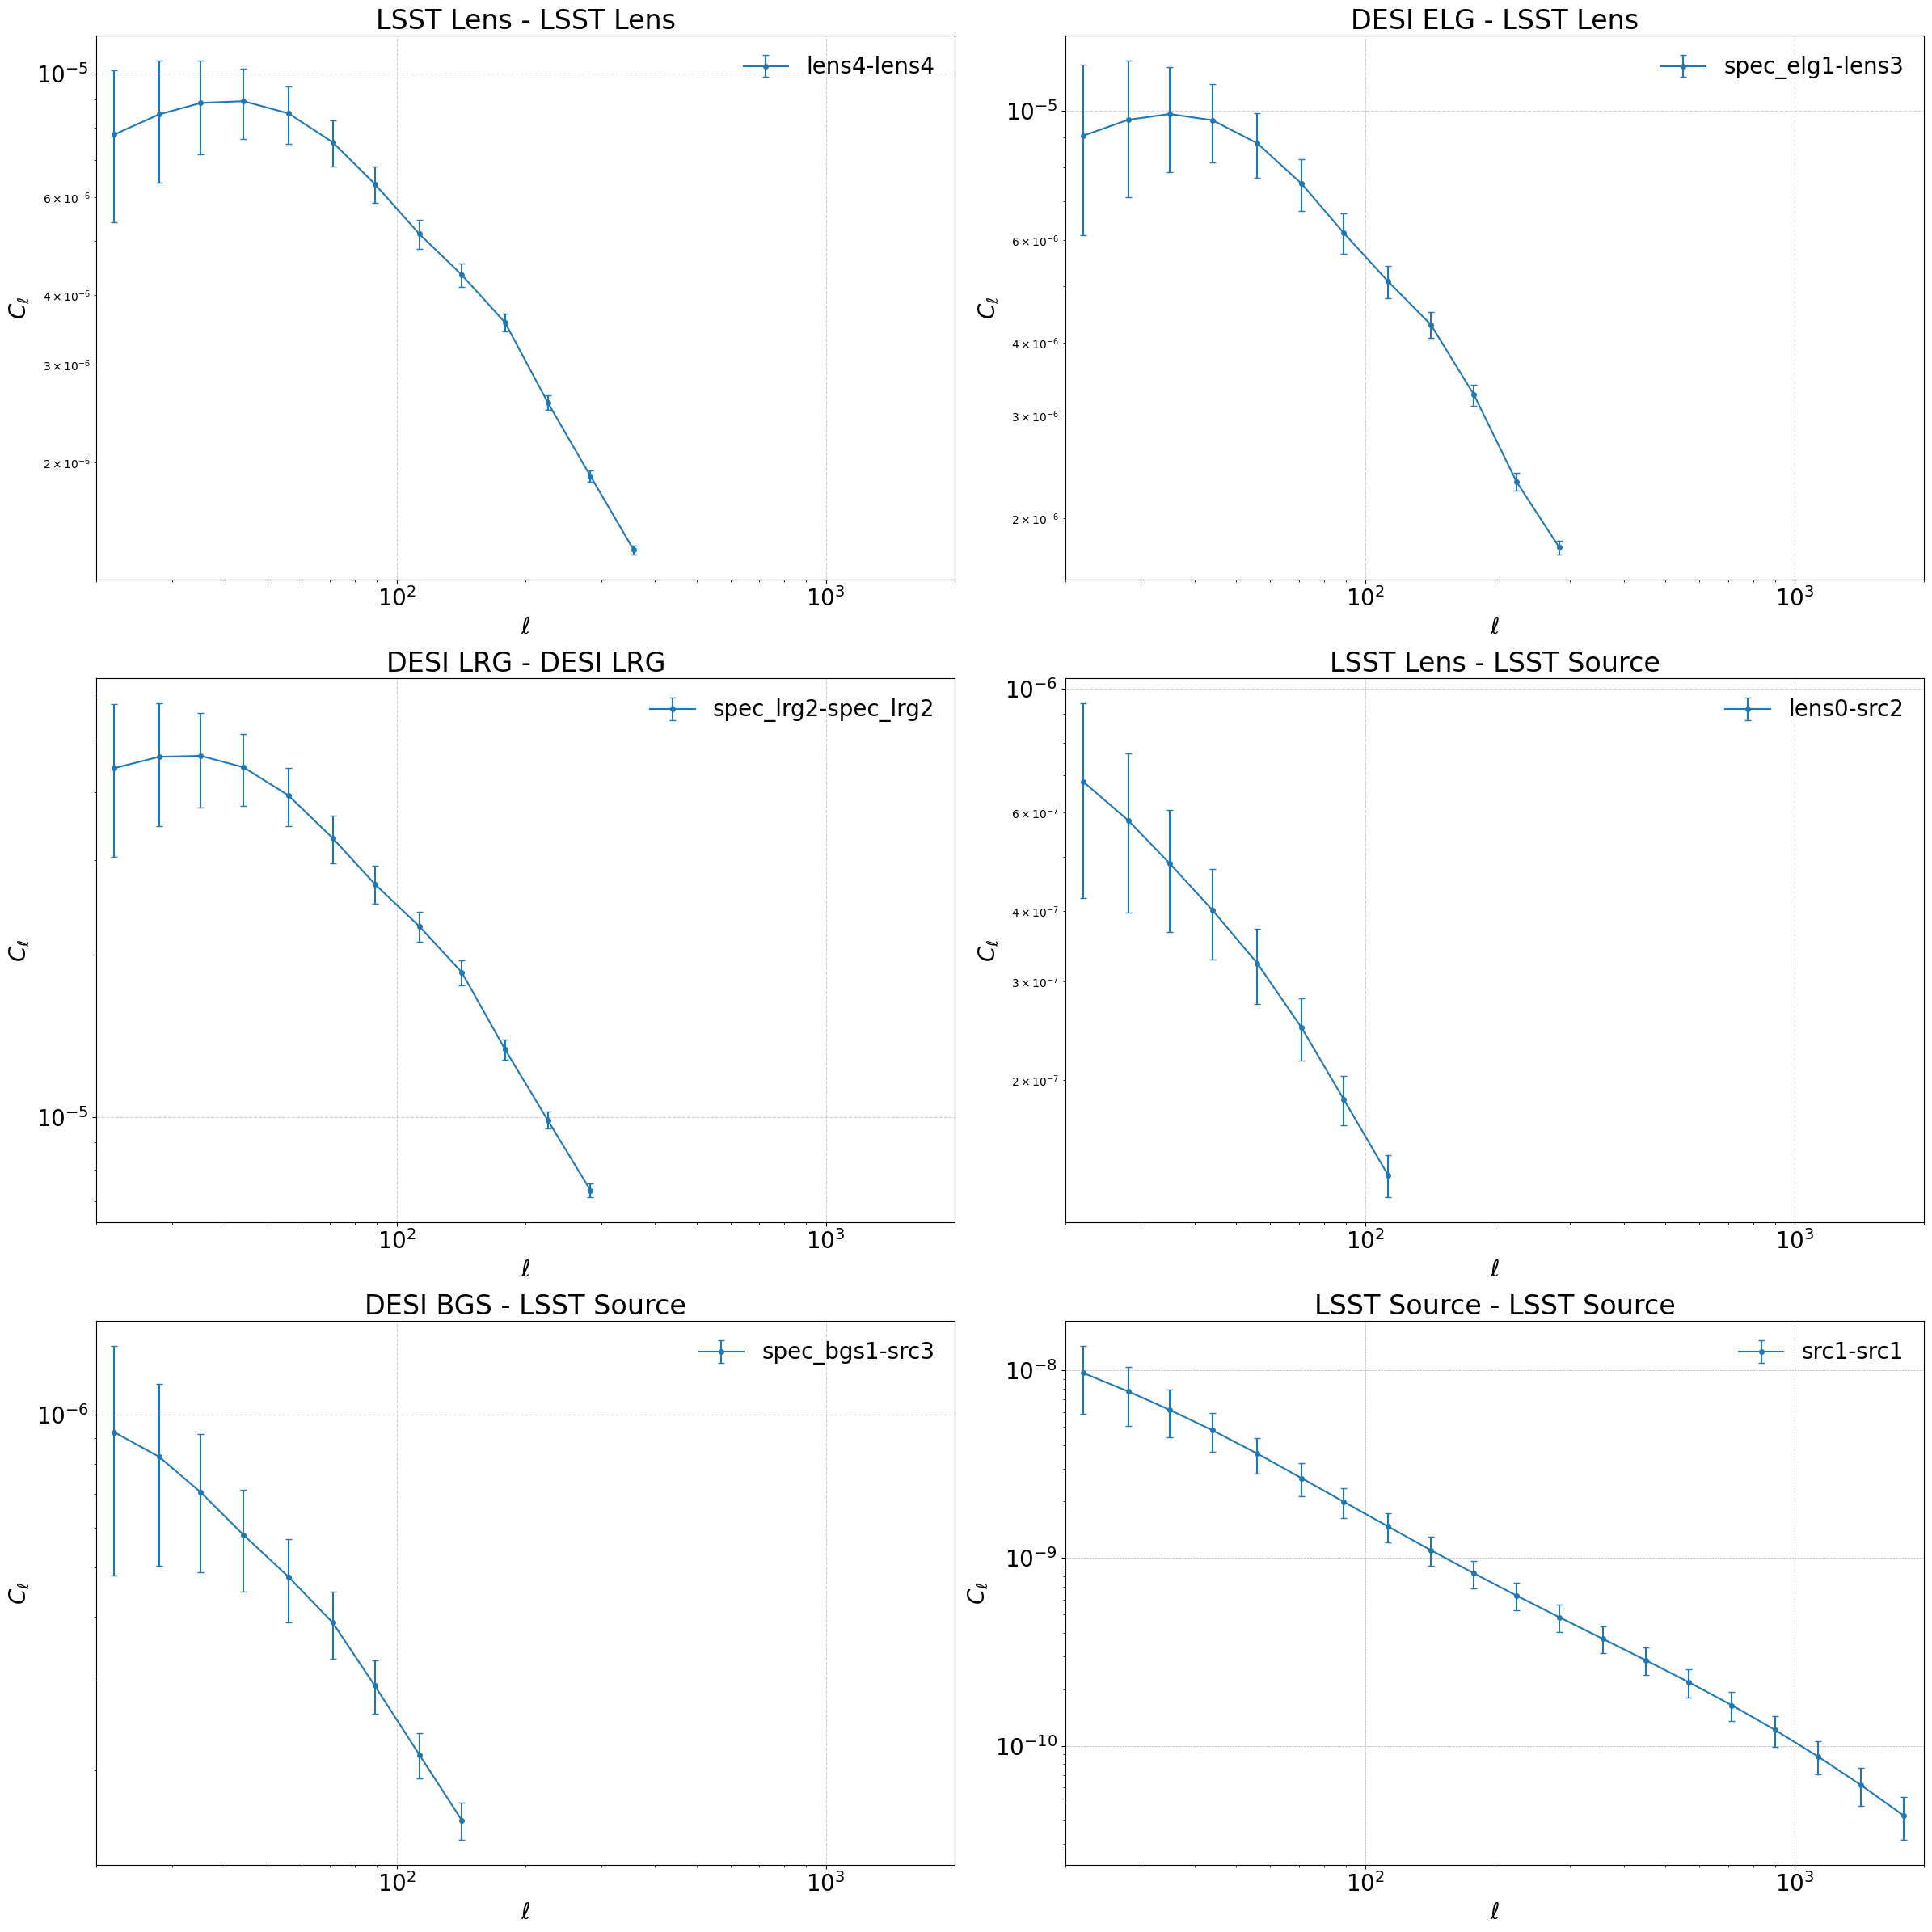

In [9]:
all_tracer_combinations = [
    ("lens4", "lens4"), ("spec_elg1", "lens3"), ("spec_lrg2", "spec_lrg2"),
    ("lens0", "src2"), ("spec_bgs1", "src3"), ("src1", "src1")
]

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(24, 24))
sacc_data1 = get_6x2pt_sacc(["run_overlap_6x2pt_LSST_DESI_FULL_0.2bin"])[0]
sacc_data2 = get_6x2pt_sacc(["run_overlapnorsd_6x2pt_LSST_DESI_FULL_0.2bin"])[0]

# Define custom ticks for log-scale axes
x_ticks = [20, 50, 100, 200, 500, 1000, 2000]  # Manually chosen ℓ values

for idx, (tr1, tr2) in enumerate(all_tracer_combinations):
    ell, C_ell, cov = sacc_data1.get_ell_cl(None, tr1, tr2, return_cov=True)
    err = np.sqrt(np.diag(cov))
    
    # Calculate row and column indices dynamically
    row, col = divmod(idx, ax.shape[1])
    
    ax[row, col].errorbar(ell, C_ell, err, fmt='-o', markersize=4, capsize=3, label=f"{tr1}-{tr2}")
    ax[row, col].set_xscale("log")
    ax[row, col].set_yscale("log")
    ax[row, col].set_xlim(20, 2000)
        
    ax[row, col].set_xlabel("$\ell$", fontsize=20)
    ax[row, col].set_ylabel("$C_\ell$", fontsize=20)
    
    # Set titles and labels
    if tr1.startswith("lens") and tr2.startswith("lens"):
        ax[row, col].set_title("LSST Lens - LSST Lens", fontsize=24)
    elif tr1.startswith("spec") and tr2.startswith("lens"):
        ax[row, col].set_title("DESI ELG - LSST Lens", fontsize=24)
    elif tr1.startswith("spec") and tr2.startswith("spec"):
        ax[row, col].set_title("DESI LRG - DESI LRG", fontsize=24)
    elif tr1.startswith("lens") and tr2.startswith("src"):
        ax[row, col].set_title("LSST Lens - LSST Source", fontsize=24)
    elif tr1.startswith("spec") and tr2.startswith("src"):
        ax[row, col].set_title("DESI BGS - LSST Source", fontsize=24)
    elif tr1.startswith("src") and tr2.startswith("src"):
        ax[row, col].set_title("LSST Source - LSST Source", fontsize=24)
    
    # ax[row, col].set_xticks(x_ticks)
    # ax[row, col].set_xticklabels([f"{x}" for x in x_ticks])
    # ax[row, col].set_yticks(y_ticks)
    # ax[row, col].set_yticklabels([f"{y:.1e}" for y in y_ticks])
    ax[row, col].tick_params(labelsize=20)
    ax[row, col].grid(True, linestyle="--", alpha=0.6)
    ax[row, col].legend(loc='upper right', fontsize=20 ,frameon=False)  # Add legend for each subplot
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

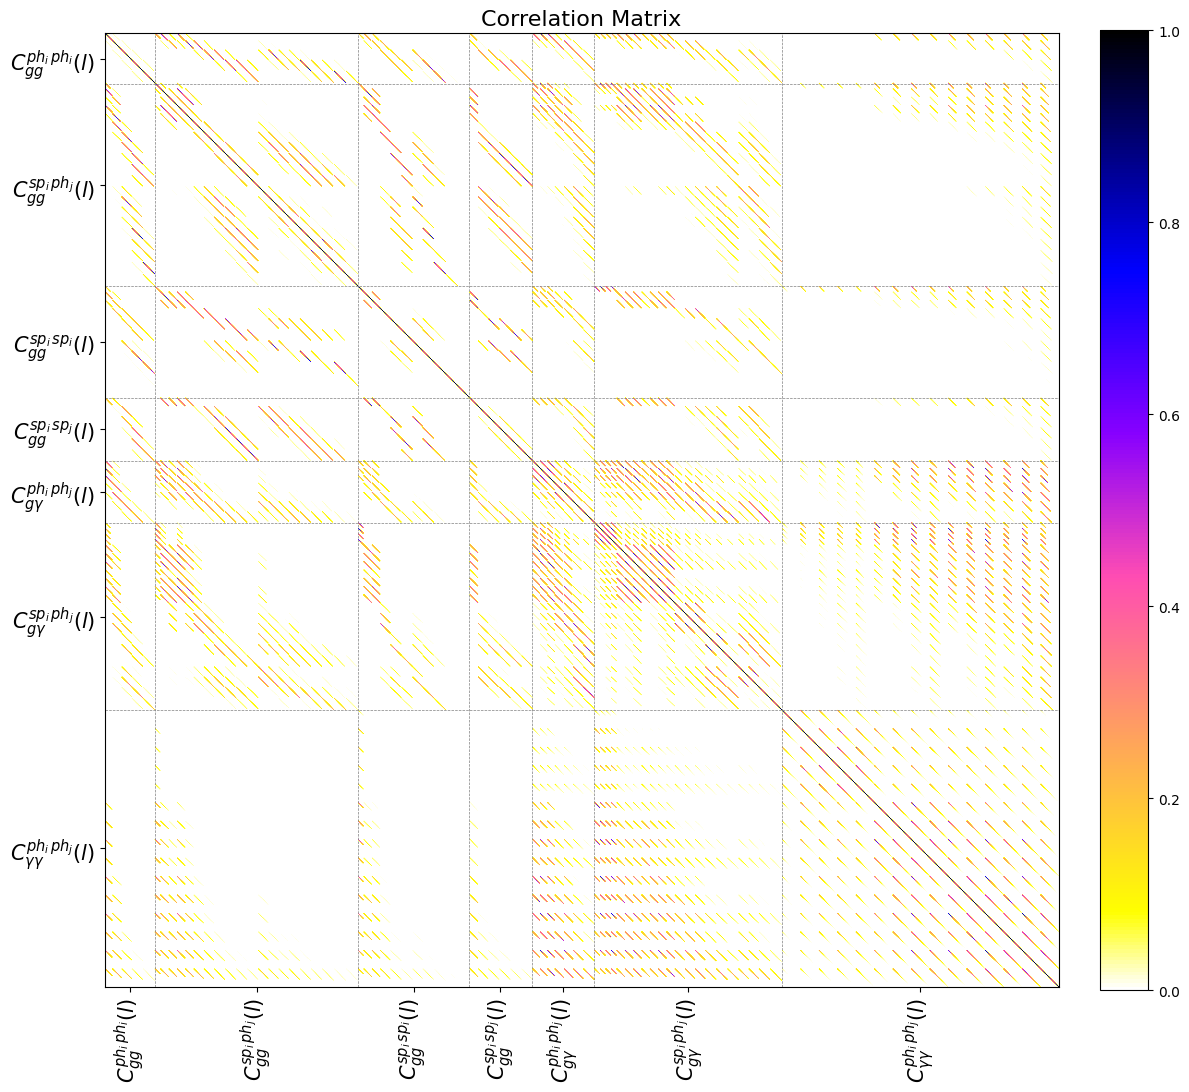

In [10]:
import pandas as pd
import numpy as np

sacc_data2 = get_6x2pt_sacc(["run_overlap_6x2pt_LSST_DESI_FULL_0.2bin"])[0]
# Ensure arrays are in native byte order
cov2 = np.asarray(sacc_data2.covariance.dense, dtype=np.float64).newbyteorder('=')
sig2 = np.sqrt(cov2.diagonal())
corr2 = cov2 / np.outer(sig2, sig2)

# Create a list of tracer cExceptionombinfrom scipy.signal import convolveations
tracer_combinations = {}
for dt in sacc_data2.get_data_types():
    for tr in sacc_data2.get_tracer_combinations(dt):
        tracer_combinations[f"{tr[0]}-{tr[1]}"] = sacc_data2.indices(dt, tr)

# Create labels for the DataFrame
labels = [f"{key}_{value}" for key, value in tracer_combinations.items()]

labels = []
for key in tracer_combinations:
    for value in tracer_combinations[key]:
        labels.append(f"{value}_{key}")
# Create the DataFrame
df_cov = pd.DataFrame(cov2, index=labels, columns=labels)

# change the index and columns of the DataFrame to the tracer combinations

order = ['lens0-lens0', 'lens1-lens1', 'lens2-lens2', 'lens3-lens3', 'lens4-lens4',
         'spec_bgs0-lens0', 'spec_bgs1-lens0', 'spec_bgs1-lens1', 'spec_lrg0-lens0', 'spec_lrg0-lens1', 'spec_lrg1-lens1', 'spec_lrg1-lens2', 'spec_lrg2-lens2', 'spec_lrg2-lens3', 'spec_lrg3-lens3', 'spec_lrg3-lens4', 'spec_elg0-lens1', 'spec_elg0-lens2', 'spec_elg0-lens3', 'spec_elg1-lens2', 'spec_elg1-lens3', 'spec_elg1-lens4', 'spec_elg2-lens3', 'spec_elg2-lens4', 'spec_elg3-lens4', 
         'spec_bgs0-spec_bgs0', 'spec_bgs1-spec_bgs1', 'spec_lrg0-spec_lrg0', 'spec_lrg1-spec_lrg1', 'spec_lrg2-spec_lrg2', 'spec_lrg3-spec_lrg3', 'spec_elg0-spec_elg0', 'spec_elg1-spec_elg1', 'spec_elg2-spec_elg2',  'spec_elg3-spec_elg3', 'spec_elg4-spec_elg4',
         'spec_bgs1-spec_lrg0', 'spec_lrg1-spec_elg0', 'spec_lrg2-spec_elg0', 'spec_lrg2-spec_elg1', 'spec_lrg3-spec_elg1', 'spec_lrg3-spec_elg2',
         'lens0-src2', 'lens0-src3', 'lens0-src4', 'lens1-src3', 'lens1-src4', 'lens2-src4', 'lens3-src4',
         'spec_bgs0-src1', 'spec_bgs0-src2', 'spec_bgs0-src3', 'spec_bgs0-src4', 'spec_bgs1-src2', 'spec_bgs1-src3', 'spec_bgs1-src4', 'spec_lrg0-src1', 'spec_lrg0-src2', 'spec_lrg0-src3', 'spec_lrg0-src4', 'spec_lrg1-src2', 'spec_lrg1-src3', 'spec_lrg1-src4', 'spec_lrg2-src3', 'spec_lrg2-src4', 'spec_lrg3-src4', 'spec_elg0-src3', 'spec_elg0-src4', 'spec_elg1-src4', 'spec_elg2-src4', 
         'src0-src0', 'src0-src1', 'src0-src2', 'src0-src3', 'src0-src4', 'src1-src1', 'src1-src2', 'src1-src3', 'src1-src4', 'src2-src2', 'src2-src3', 'src2-src4', 'src3-src3', 'src3-src4', 'src4-src4']

labels_new = []
for tracer in order:
    for label in labels:
        if label.endswith(tracer):
            labels_new.append(label)
            pass

df_cov = df_cov.reindex(index=labels_new, columns=labels_new)
    
cov2 = np.asarray(df_cov.values, dtype=np.float64).newbyteorder('=')
sig2 = np.sqrt(cov2.diagonal())
corr2 = cov2 / np.outer(sig2, sig2)

plt.figure(figsize=(12, 12))
# Plota a matriz de correlação no subplot correspondente
im = plt.imshow(corr2, vmin=0, vmax=1, cmap='gnuplot2_r')
plt.title(f'Correlation Matrix', fontsize=16)

# Obtém os rótulos para os eixos x e y
labels = ["$C^{ph_i \, ph_i }_{gg}(l)$", "$C^{sp_i\,ph_j}_{gg}(l)$", "$C^{sp_i\,sp_i}_{gg}(l)$", "$C^{sp_i\,sp_j}_{gg}(l)$", "$C^{ph_i\,ph_j}_{g\gamma}(l)$", "$C^{sp_i\,ph_j}_{g\gamma}(l)$", "$C^{ph_i\,ph_j}_{\gamma\gamma}(l)$"]

# Adiciona linhas divisórias para diferenciar os blocos
block_indices = [54.5, 273.5, 394.5, 462.5, 529.5, 732.5, 1033]

# Calcula as posições dos ticks (meio de cada bloco)
tick_positions = []
start = 0
for block in block_indices:
    mid = (start + block) // 2  # Ponto médio do bloco
    tick_positions.append(mid)
    start = block

# Remove o último índice, pois não precisamos de uma linha no final da matriz
block_indices = block_indices[:-1]

# Define os ticks e rótulos nos eixos x e y
plt.xticks(tick_positions)
plt.yticks(tick_positions)
plt.xticks(tick_positions, labels, rotation=90, fontsize=15)  # Rótulos no eixo x
plt.yticks(tick_positions, labels, fontsize=15)  # Rótulos no eixo y

# Adiciona linhas divisórias para diferenciar os blocos
for block in block_indices:
    plt.axvline(x=block, color='grey', linestyle='--', linewidth=0.5)
    plt.axhline(y=block, color='grey', linestyle='--', linewidth=0.5)
    # Adjust the size of the colorbar


cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
# cbar.set_label('Correlation', fontsize=16)
plt.tight_layout()
plt.show()
